# Seville CMIP6 SSP5-8.5 Projection EDA (2026-2045)

Applies the same processing and indicator-calculation pipeline used in `seville_era5_eda.ipynb` to
the CMIP6 `cmcc_esm2` SSP5-8.5 projection pulled by `pull_cmip6_projections.py`, wherever that
pipeline actually transfers to daily-native projection data. Sections that don't apply (6-hourly
resampling, wind-direction/rose, sub-daily heat index) are dropped rather than faked; sections that
would silently redefine a "fixed" threshold from the projection data itself (the P90 heatwave
threshold) instead load and reuse the threshold already fit on the ERA5 1990-2020 reference period,
per `fixed_reference_period_principle.md`.

**Source data:** `data/seville_cmip6_ssp585_2026_2045.csv` (model `cmcc_esm2`, experiment
`ssp5_8_5`, 4 grid points in the Seville bounding box, 2026-01-01 to 2045-12-31).

**Historical reference** (for fixed thresholds and the ERA5-vs-projection comparison):
`eda_results/eda_outputs/seville_daily.csv` and `annual_summary.csv`, from `seville_era5_eda.ipynb`.

**Known limitations, stated once here rather than repeated throughout:** raw (non-bias-corrected)
CMIP6 output at a single grid box, one model, one scenario -- see
`documentation/projection_data_pull_plan.md` Step 6 and `project_summary.md`'s "illustrative of
directional risk rather than definitive climate-model consensus" framing. Sections 1-11 work
entirely with raw output; Section 12 applies an Equidistant CDF Matching bias correction, and
Sections 13-16 recompute every indicator (heatwaves, hot days, wet-day stats, trends) on that
corrected series with an explicit before/after comparison. Full breakdown of what carries over vs.
what doesn't is in Section 17 below.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)

RAW_CSV = Path("../data/seville_cmip6_ssp585_2026_2045.csv")
ERA5_DAILY_CSV = Path("../../Historical/eda_outputs/seville/seville_daily.csv")
ERA5_ANNUAL_CSV = Path("../../Historical/eda_outputs/seville/annual_summary.csv")
OUT = Path("../eda_outputs/seville")
OUT.mkdir(parents=True, exist_ok=True)

# Fixed reference period -- used only to fit thresholds below, never refit on new data.
# See fixed_reference_period_principle.md.
REFERENCE_START, REFERENCE_END = 1990, 2020

## 1. Load the raw CMIP6 pull

`pull_cmip6_projections.py` merges 7 separately-downloaded variables on `(valid_time, lat, lon)`,
but each variable also carries its own 2-valued `bnds` dimension (from `time_bnds`/`lat_bnds`/
`lon_bnds`) that isn't part of the merge key -- 6 successive merges of a 2-valued, unmerged
dimension multiply row count by 2**6 = 64. Every "duplicate" row is value-identical (confirmed by
`nunique()==1` per group before writing this notebook), so it doesn't bias any mean computed
downstream, but it inflates the frame ~64x for no reason and would make row-count sanity checks
misleading if left in. Dropped explicitly below, as a documented QC step.

In [2]:
raw = pd.read_csv(RAW_CSV, parse_dates=["valid_time"])
print(f"raw shape: {raw.shape}")
print(raw.columns.tolist())

BNDS_COLS = ["bnds", "time_bnds", "lat_bnds", "lon_bnds", "height"]
df = raw.drop(columns=[c for c in BNDS_COLS if c in raw.columns]).drop_duplicates().reset_index(drop=True)

n_days = df["valid_time"].nunique()
n_points = df[["lat", "lon"]].drop_duplicates().shape[0]
print(f"deduped shape: {df.shape}  (expected {n_days} days x {n_points} grid points = {n_days * n_points})")
assert df.shape[0] == n_days * n_points, "dedup did not fully resolve the bnds cross-join"
df.head()

raw shape: (29200, 12)
['valid_time', 'lat', 'lon', 'tas', 'tasmax', 'tasmin', 'pr', 'huss', 'sfcWind', 'psl', 'precip_mm_day', 'relative_humidity_pct']
deduped shape: (29200, 12)  (expected 7300 days x 4 grid points = 29200)


,valid_time,lat,lon,tas,tasmax,tasmin,pr,huss,sfcWind,psl,precip_mm_day,relative_humidity_pct
0,2026-01-01,37.225131,353.75,288.03412,291.29816,285.83078,1.306086e-06,0.008294,1.879336,102753.700,0.112846,80.715540
1,2026-01-01,37.225131,355.00,286.91867,290.48430,284.60208,4.477200e-07,0.007775,1.689602,102821.720,0.038683,81.401140
2,2026-01-01,38.167539,353.75,286.11728,289.69455,283.57596,1.613395e-06,0.008075,1.324884,102784.200,0.139397,89.018105
3,2026-01-01,38.167539,355.00,285.58360,289.15518,282.59970,1.024803e-07,0.007589,1.204583,102849.266,0.008854,86.715810
4,2026-01-02,37.225131,353.75,287.52008,291.73572,284.50742,1.280851e-06,0.008072,2.897154,102269.280,0.110666,80.824820


## 2. Physical plausibility check

Same spirit as the ERA5 notebook's bounds check (its section 2), with CMIP6-appropriate ranges:
temperature is still in Kelvin, `pr` is a flux (kg/m2/s, tiny values), `psl` is in Pa, `huss` is
specific humidity (kg/kg, small), `sfcWind` is a scalar speed in m/s.

In [3]:
BOUNDS = {
    "tas": (250, 325), "tasmax": (250, 330), "tasmin": (245, 320),
    "pr": (0, 0.005),           # kg m-2 s-1 -- 0.005 corresponds to ~430 mm/day, a generous upper bound
    "huss": (0, 0.03),
    "sfcWind": (0, 40),
    "psl": (90000, 108000),
    "precip_mm_day": (0, 400),
    "relative_humidity_pct": (0, 100),
}
for col, (lo, hi) in BOUNDS.items():
    if col not in df.columns:
        continue
    n_bad = (~df[col].between(lo, hi)).sum()
    print(f"{col:24s} range=({df[col].min():.4g}, {df[col].max():.4g})  out-of-bounds={n_bad}")

# precip_mm_day carries tiny floating-point negative noise (~-1e-4) from the flux conversion at
# near-zero rainfall -- clip rather than treat it as a QC failure.
df["precip_mm_day"] = df["precip_mm_day"].clip(lower=0)

tas                      range=(276.5, 313.8)  out-of-bounds=0
tasmax                   range=(279.4, 319.7)  out-of-bounds=0
tasmin                   range=(272.7, 308.5)  out-of-bounds=0
pr                       range=(-2.038e-19, 0.0006276)  out-of-bounds=44
huss                     range=(0.001658, 0.01824)  out-of-bounds=0
sfcWind                  range=(0.6473, 9.239)  out-of-bounds=0
psl                      range=(9.992e+04, 1.044e+05)  out-of-bounds=0
precip_mm_day            range=(-1.761e-14, 54.22)  out-of-bounds=44
relative_humidity_pct    range=(9.001, 100)  out-of-bounds=0


## 3. Unit conversions

Temperature: the same `- 273.15` Kelvin to Celsius conversion the ERA5 pipeline used. Precipitation,
specific humidity, wind speed, and relative humidity are already in their final units/derived form
(`pull_cmip6_projections.py` did the `pr x 86400` flux conversion and the specific-humidity to RH
Magnus-formula derivation upstream) -- nothing left to convert for those.

In [4]:
df["tas_c"] = df["tas"] - 273.15
df["tasmax_c"] = df["tasmax"] - 273.15
df["tasmin_c"] = df["tasmin"] - 273.15
df[["tas_c", "tasmax_c", "tasmin_c"]].describe()

,tas_c,tasmax_c,tasmin_c
count,29200.000000,29200.000000,29200.000000
mean,20.818082,25.356586,16.481169
std,8.154220,8.648257,7.505419
min,3.334400,6.298150,-0.404060
25%,13.522345,17.621683,9.930825
50%,20.001290,24.588970,15.720840
75%,28.013220,32.988260,22.980623
max,40.686000,46.535200,35.328450


## 4. Grid-point averaging (4 points to 1 daily series)

Same unweighted arithmetic mean the ERA5 pipeline used (no distance/area weighting there either).
Relative humidity is a nonlinear function of temperature, humidity, and pressure, so -- matching
the ERA5 notebook's own discipline of recomputing RH from averaged inputs rather than averaging RH
itself -- it's recomputed here from the grid-averaged `tas`/`huss`/`psl`, using the identical
Magnus-formula derivation `pull_cmip6_projections.py` used per grid point.

In [5]:
BASE = ["tas", "tasmax", "tasmin", "tas_c", "tasmax_c", "tasmin_c",
        "precip_mm_day", "sfcWind", "huss", "psl"]

sev = df.groupby("valid_time")[BASE].mean()

def derive_rh(tas_k, huss, psl_pa):
    """Identical formula to pull_cmip6_projections.py's per-grid-point derivation, applied here
    to the grid-averaged base variables instead -- mirrors the ERA5 notebook's rule of recomputing
    nonlinear quantities from averaged inputs, not averaging the nonlinear output directly."""
    t_c = tas_k - 273.15
    p_hpa = psl_pa / 100.0
    q = huss
    vapor_pressure = q * p_hpa / (0.622 + 0.378 * q)
    sat_vapor_pressure = 6.112 * np.exp(17.62 * t_c / (243.12 + t_c))
    return np.clip(100 * vapor_pressure / sat_vapor_pressure, 0, 100)

sev["relative_humidity_pct"] = derive_rh(sev["tas"], sev["huss"], sev["psl"])
sev.head()

,tas,tasmax,tasmin,tas_c,tasmax_c,tasmin_c,precip_mm_day,sfcWind,huss,psl,relative_humidity_pct
valid_time,,,,,,,,,,,
2026-01-01,286.663417,290.158048,284.152130,13.513418,17.008048,11.002130,0.074945,1.524601,0.007933,102802.22150,84.421063
2026-01-02,286.222168,290.413757,283.296740,13.072168,17.263758,10.146740,0.096145,2.830201,0.007599,102372.60250,82.895557
2026-01-03,286.875077,292.167925,283.682037,13.725078,19.017925,10.532038,0.071974,1.537889,0.007280,102412.93025,76.147755
2026-01-04,286.315275,290.876410,283.052990,13.165275,17.726410,9.902990,0.120777,2.455635,0.006723,102747.02500,73.195486
2026-01-05,285.727307,289.661513,283.144360,12.577308,16.511513,9.994360,0.073602,2.850088,0.006654,102584.86275,75.166192


## 5. Daily frame

CMIP6's `projections-cmip6` dataset already provides true daily `tasmax`/`tasmin`, not an
approximation from sparse sub-daily samples -- so unlike the ERA5 pipeline (which resampled
6-hourly data with `.resample("D").max()/.min()/.sum()`), there's no resampling step here at all;
`sev` (indexed by `valid_time`, already one row per day) *is* the daily frame. Columns are renamed
to match the ERA5 notebook's naming convention so the indicator-calculation code below is close to
a direct port.

One genuine definitional gap: `heat_index_c` here is computed once per day from the single daily
mean temperature/RH CMIP6 provides, not (as in the ERA5 pipeline) the max of six intra-day
heat-index samples -- there's no sub-daily data to take a max over. It is **not** the same quantity
as the historical `heat_index_max_c` and is named differently here to avoid implying otherwise.

In [6]:
def compute_heat_index(t_c, rh):
    """Identical NWS Rothfusz fit used in the ERA5 notebooks (degF internally, converted back to degC)."""
    t_f = t_c * 9 / 5 + 32
    simple = 0.5 * (t_f + 61.0 + (t_f - 68.0) * 1.2 + rh * 0.094)
    hi_f = (-42.379 + 2.04901523 * t_f + 10.14333127 * rh - 0.22475541 * t_f * rh - 6.83783e-3 * t_f**2
            - 5.481717e-2 * rh**2 + 1.22874e-3 * t_f**2 * rh + 8.5282e-4 * t_f * rh**2 - 1.99e-6 * t_f**2 * rh**2)
    return (np.where(t_f < 80, simple, hi_f) - 32) * 5 / 9

daily = pd.DataFrame({
    "tmax_c": sev["tasmax_c"],
    "tmin_c": sev["tasmin_c"],
    "tmean_c": sev["tas_c"],
    "precip_mm_day": sev["precip_mm_day"],
    "wind_avg": sev["sfcWind"],
    "rh_mean_percent": sev["relative_humidity_pct"],
})
daily["dtr_c"] = daily["tmax_c"] - daily["tmin_c"]
daily["heat_index_c"] = compute_heat_index(daily["tmean_c"], daily["rh_mean_percent"])
daily["year"] = daily.index.year
daily["month"] = daily.index.month

daily.to_csv(OUT / "seville_projection_daily.csv")
daily.describe()

,tmax_c,tmin_c,tmean_c,precip_mm_day,wind_avg,rh_mean_percent,dtr_c,heat_index_c,year,month
count,7300.000000,7300.000000,7300.000000,7.300000e+03,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000
mean,25.356586,16.481169,20.818082,6.798493e-01,2.584132,51.388516,8.875417,19.999490,2035.500000,6.526027
std,8.592796,7.444726,8.108147,2.349795e+00,0.859514,21.113973,2.413172,8.055656,5.766676,3.448088
min,7.335250,0.779128,4.512483,0.000000e+00,0.771646,11.138032,1.086467,2.202162,2026.000000,1.000000
25%,17.594731,9.912374,13.469923,1.261216e-09,1.923196,32.612097,7.267829,12.712191,2030.750000,4.000000
50%,24.626371,15.731883,19.959021,3.912565e-03,2.488041,49.616848,8.994070,19.334878,2035.500000,7.000000
75%,32.956796,23.045046,28.016579,1.657848e-01,3.124460,70.325779,10.535733,27.333627,2040.250000,10.000000
max,46.065995,34.211470,39.935970,4.457985e+01,7.187507,99.763938,17.458957,38.339526,2045.000000,12.000000


## 6. Fixed reference-period thresholds (loaded from ERA5, 1990-2020, never refit here)

The ERA5 notebook's percentile-based heatwave detection computes a calendar-day P90 threshold
(`tmax_c`, +/-7-day window, pooled across years) inline from whatever `daily` frame is in scope. If
that code were copy-pasted unmodified into this notebook, `daily` would be the *projection* frame,
and the P90 baseline would be silently redefined from 2026-2045 data -- exactly the shifting-baseline
failure `fixed_reference_period_principle.md` warns against, and precisely backwards for a
comparison whose entire point is "how do projected hot days compare to the historical normal." The
threshold is instead computed once here from the ERA5 historical daily series, restricted to the
documented 1990-2020 reference period (the ERA5 notebook itself pooled its full 1990-2025 record
when computing this threshold inline -- a minor inconsistency with the documented principle, not
repeated here).

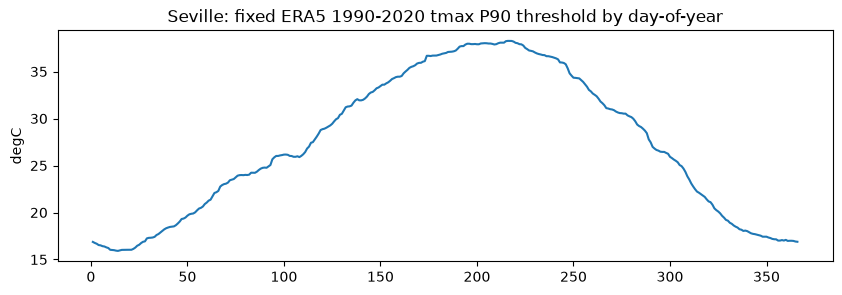

In [7]:
era5_daily = pd.read_csv(ERA5_DAILY_CSV, parse_dates=["valid_time"])
era5_daily["year"] = era5_daily["valid_time"].dt.year
ref = era5_daily[era5_daily["year"].between(REFERENCE_START, REFERENCE_END)].copy()
ref["doy"] = ref["valid_time"].dt.dayofyear

tmax_p90_by_doy = {}
for doy in range(1, 367):
    window = [((doy - 1 + k) % 366) + 1 for k in range(-7, 8)]
    tmax_p90_by_doy[doy] = ref.loc[ref["doy"].isin(window), "tmax_c"].quantile(0.90)

pd.Series(tmax_p90_by_doy).plot(
    title="Seville: fixed ERA5 1990-2020 tmax P90 threshold by day-of-year", figsize=(10, 3))
plt.ylabel("degC")
plt.show()

## 7. Indicator calculation

Hot-day threshold counts and the tropical-night threshold are fixed absolute values in the ERA5
notebook (not fit from data), so they carry over unchanged. Heatwaves apply the fixed P90-by-doy
dict from Section 6 to the *projection's* `tmax_c`, with the same >=3-consecutive-day run
requirement.

In [8]:
THRESH = [30, 33, 35, 37, 40]

d = daily.copy()
d["doy"] = d.index.dayofyear
d["tmax_p90"] = d["doy"].map(tmax_p90_by_doy)
d["exceed"] = d["tmax_c"] > d["tmax_p90"]

grp = (d["exceed"] != d["exceed"].shift()).cumsum()
runs = (d[d["exceed"]]
        .groupby(grp[d["exceed"]])
        .agg(start=("tmax_c", lambda s: s.index.min()),
             length=("tmax_c", "size"),
             peak=("tmax_c", "max"),
             mean_tmax=("tmax_c", "mean")))
heatwaves = runs[runs["length"] >= 3].reset_index(drop=True)
heatwaves["year"] = pd.to_datetime(heatwaves["start"]).dt.year
heatwaves.to_csv(OUT / "seville_projection_heatwave_events.csv", index=False)

hot = pd.DataFrame({
    f"days tmax>={t} C": d.groupby("year")["tmax_c"].apply(lambda s, t=t: (s >= t).sum())
    for t in THRESH
})
hot["tropical nights tmin>=20 C"] = d.groupby("year")["tmin_c"].apply(lambda s: int((s >= 20).sum()))
hot["days heat index>=35 C"] = d.groupby("year")["heat_index_c"].apply(lambda s: int((s >= 35).sum()))

hw_year = heatwaves.groupby("year").agg(
    heatwaves=("length", "size"),
    **{"heatwave days": ("length", "sum"), "longest (days)": ("length", "max")},
)

print(f"{len(heatwaves)} heatwave events detected, {heatwaves['year'].nunique()} distinct years")
hot.tail()

299 heatwave events detected, 20 distinct years


,days tmax>=30 C,days tmax>=33 C,days tmax>=35 C,days tmax>=37 C,days tmax>=40 C,tropical nights tmin>=20 C,days heat index>=35 C
year,,,,,,,
2041,134,102,84,62,22,146,10
2042,119,82,75,45,4,122,3
2043,132,101,71,42,6,142,0
2044,144,110,76,56,23,156,6
2045,131,100,74,50,12,137,4


## 8. Wet-day and precipitation extremes

`precip_mm_day` is already a true daily total (`pr x 86400`, done in `pull_cmip6_projections.py`)
-- unlike ERA5's `tp`, which only sampled 4 times a day and needed the `x6` undercount correction
(`PRECIP_SCALE`) before use. That correction does not apply here and is not reused; `precip_mm_day`
is used directly as the "already-scaled" equivalent of the ERA5 notebook's `precip_mm_scaled`. The
1 mm/day wet-day threshold and all four spell/intensity metrics are otherwise unchanged.

In [9]:
WET = 1.0
d["is_wet"] = d["precip_mm_day"] >= WET

def max_dry_run(is_wet):
    dry_flag = (~is_wet).astype(int)
    run_id = (is_wet != is_wet.shift()).cumsum()
    return int(dry_flag.groupby(run_id).sum().max())

wetstats = d.groupby("year").apply(lambda g: pd.Series({
    "wet days": int(g["is_wet"].sum()),
    "mean intensity (mm/wet day)": g.loc[g["is_wet"], "precip_mm_day"].mean(),
    "max 1-day (mm)": g["precip_mm_day"].max(),
    "P95 wet-day (mm)": g.loc[g["is_wet"], "precip_mm_day"].quantile(0.95),
    "longest dry spell (days)": max_dry_run(g["is_wet"]),
}), include_groups=False)
wetstats.tail()

,wet days,mean intensity (mm/wet day),max 1-day (mm),P95 wet-day (mm),longest dry spell (days)
year,,,,,
2041,19.0,5.561727,20.788176,15.534630,89.0
2042,28.0,3.973305,11.954295,8.604784,95.0
2043,41.0,3.856311,13.123138,10.395853,54.0
2044,44.0,3.793808,16.970483,8.538223,133.0
2045,73.0,5.507260,21.951486,14.789769,103.0


## 9. Annual summary and export

In [10]:
annual = pd.DataFrame({
    "tas_mean": d.groupby("year")["tmean_c"].mean(),
    "rh_mean": d.groupby("year")["rh_mean_percent"].mean(),
    "heat_index_mean": d.groupby("year")["heat_index_c"].mean(),
    "wind_mean": d.groupby("year")["wind_avg"].mean(),
    "tas_p95": d.groupby("year")["tmean_c"].quantile(0.95),
    "tas_p05": d.groupby("year")["tmean_c"].quantile(0.05),
    "tmax_mean": d.groupby("year")["tmax_c"].mean(),
    "tmin_mean": d.groupby("year")["tmin_c"].mean(),
    "precip_total": d.groupby("year")["precip_mm_day"].sum(),
})

annual_summary = annual.join(hot, how="left").join(hw_year, how="left").join(wetstats, how="left")
for col in ["heatwaves", "heatwave days", "longest (days)"]:
    annual_summary[col] = annual_summary[col].fillna(0).astype(int)

annual_summary.to_csv(OUT / "seville_projection_annual_summary.csv")
annual_summary

,tas_mean,rh_mean,heat_index_mean,wind_mean,tas_p95,tas_p05,tmax_mean,tmin_mean,precip_total,days tmax>=30 C,...,tropical nights tmin>=20 C,days heat index>=35 C,heatwaves,heatwave days,longest (days),wet days,mean intensity (mm/wet day),max 1-day (mm),P95 wet-day (mm),longest dry spell (days)
year,,,,,,,,,,,,,,,,,,,,,
2026,20.697938,51.248320,19.771776,2.541481,33.552416,10.326944,25.267205,16.329307,241.177639,130,...,132,0,14,92,11,42.0,5.278827,20.382944,10.352728,109.0
2027,20.002315,48.716215,19.119348,2.619683,31.541975,10.044336,24.382082,15.751674,231.346109,110,...,123,0,12,58,11,32.0,6.247478,24.534125,16.069318,128.0
2028,21.852625,44.529562,20.840297,2.463245,35.303545,9.004392,26.514646,17.286086,70.970154,145,...,144,5,16,124,17,19.0,2.904290,5.533037,5.229487,117.0
2029,20.901717,48.231925,19.912280,2.654145,33.641611,8.097989,25.254938,16.633795,261.040783,130,...,142,1,15,93,11,37.0,6.382925,44.579852,21.353383,106.0
2030,19.779925,50.733813,18.845411,2.635631,33.761089,8.831488,24.129468,15.555983,203.225641,105,...,117,3,8,51,12,48.0,3.805459,10.455863,8.926045,60.0
2031,20.125325,56.796336,19.451868,2.719948,32.295937,10.439081,24.402331,16.079242,471.297551,110,...,124,2,11,58,10,90.0,4.936521,26.077076,14.840171,57.0
2032,21.013205,54.142818,20.360633,2.503748,33.005553,11.086107,25.599811,16.717128,221.468868,116,...,118,0,20,131,18,45.0,4.396167,22.902406,12.713657,95.0
2033,21.321890,53.194231,20.609384,2.501844,34.255475,9.396044,26.114627,16.884572,287.729789,141,...,144,6,19,119,14,46.0,5.572046,23.372402,19.045681,140.0
2034,20.255161,52.892760,19.362973,2.504283,33.877478,8.649690,24.876167,15.840428,284.208276,112,...,122,0,11,82,15,55.0,4.740995,31.654273,11.146508,118.0


## 10. Trend within the projection period (2026-2045)

Same `trend_table()` used throughout the ERA5 notebook (OLS, Theil-Sen, Kendall tau), applied here
to the projection's own 20-year annual series. A 20-year window has much less statistical power
than the ERA5 pipeline's 36-year record, and this is a single model/scenario run, not an ensemble
-- treat any trend found here as suggestive of SSP5-8.5-under-cmcc_esm2 direction, not as a robust,
standalone trend estimate the way the ERA5 trends are.

In [11]:
def trend_table(frame, cols, per_decade=True):
    scale = 10.0 if per_decade else 1.0
    x = frame.index.values.astype(float)
    rows = []
    for c in cols:
        y = frame[c].values.astype(float)
        lr = stats.linregress(x, y)
        ts_slope, ts_int, ts_lo, ts_hi = stats.theilslopes(y, x, 0.95)
        tau, tau_p = stats.kendalltau(x, y)
        rows.append({
            "variable": c,
            "OLS slope/decade": lr.slope * scale,
            "OLS p-value": lr.pvalue,
            "Theil-Sen slope/decade": ts_slope * scale,
            "Theil-Sen 95% CI low": ts_lo * scale,
            "Theil-Sen 95% CI high": ts_hi * scale,
            "Kendall tau": tau,
            "tau p-value": tau_p,
            "significant (p<0.05)": lr.pvalue < 0.05,
        })
    return pd.DataFrame(rows).set_index("variable")

TREND_COLS = ["tas_mean", "heat_index_mean", "tas_p95", "tmax_mean", "tmin_mean", "precip_total"]
proj_trends = trend_table(annual_summary, TREND_COLS)
proj_trends.to_csv(OUT / "seville_projection_trends.csv")
proj_trends

,OLS slope/decade,OLS p-value,Theil-Sen slope/decade,Theil-Sen 95% CI low,Theil-Sen 95% CI high,Kendall tau,tau p-value,significant (p<0.05)
variable,,,,,,,,
tas_mean,0.382124,0.146466,0.440662,-0.240042,0.936363,0.221053,0.185883,False
heat_index_mean,0.447344,0.083922,0.478591,-0.267623,1.027427,0.242105,0.145844,False
tas_p95,0.587945,0.144771,0.581653,-0.179753,1.378972,0.252632,0.128414,False
tmax_mean,0.375728,0.188751,0.487114,-0.207229,1.064848,0.221053,0.185883,False
tmin_mean,0.386968,0.125564,0.407184,-0.202463,0.935837,0.210526,0.208628,False
precip_total,1.535801,0.969303,-17.816312,-83.310413,86.102822,-0.084211,0.630799,False


## 11. Comparing the projection against the ERA5 historical baseline

`Climate_Indicators_Modeling.ipynb`'s Section 10 sketched this comparison in prose, before the
projection pull existed: extrapolate the ERA5-selected `tmax_mean` model (`ols_last_20yr`, fit on
2006-2025) forward through 2026-2045, and compare it against the CMIP6 projection's own `tmax_mean`
for the same years. The gap between the two is the actual finding -- it separates "how much warming
does the historical trend alone predict" from "how much warming does the SSP5-8.5 scenario, as
realized by cmcc_esm2, actually show."

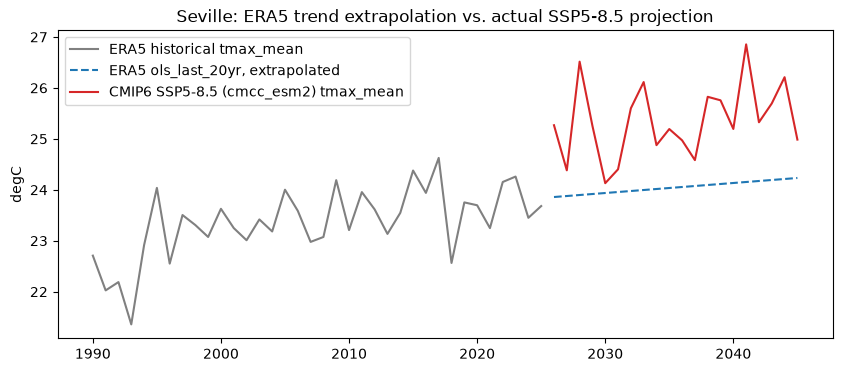

Mean gap 2026-2045: +1.31 degC (positive = SSP5-8.5 projection warmer than the historical-trend extrapolation)


,cmip6_tmax_mean,era5_ols_last20yr_extrapolated,gap_c
year,,,
2026,25.267205,23.858188,1.409017
2027,24.382082,23.877849,0.504233
2028,26.514646,23.897510,2.617136
2029,25.254938,23.917171,1.337767
2030,24.129468,23.936831,0.192636
2031,24.402331,23.956492,0.445839
2032,25.599811,23.976153,1.623658
2033,26.114627,23.995814,2.118813
2034,24.876167,24.015475,0.860693


In [12]:
era5_annual = pd.read_csv(ERA5_ANNUAL_CSV, index_col="year")
last20 = era5_annual.loc[2006:2025, "tmax_mean"]
lr = stats.linregress(last20.index.values.astype(float), last20.values.astype(float))

proj_years = annual_summary.index.values.astype(float)
era5_extrapolated = lr.intercept + lr.slope * proj_years

comparison = pd.DataFrame({
    "cmip6_tmax_mean": annual_summary["tmax_mean"],
    "era5_ols_last20yr_extrapolated": era5_extrapolated,
}, index=annual_summary.index)
comparison["gap_c"] = comparison["cmip6_tmax_mean"] - comparison["era5_ols_last20yr_extrapolated"]
comparison.to_csv(OUT / "seville_projection_vs_era5_extrapolation.csv")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(era5_annual.index, era5_annual["tmax_mean"], label="ERA5 historical tmax_mean", color="gray")
ax.plot(proj_years, era5_extrapolated, "--", label="ERA5 ols_last_20yr, extrapolated", color="tab:blue")
ax.plot(proj_years, annual_summary["tmax_mean"], label="CMIP6 SSP5-8.5 (cmcc_esm2) tmax_mean", color="tab:red")
ax.set_ylabel("degC")
ax.set_title("Seville: ERA5 trend extrapolation vs. actual SSP5-8.5 projection")
ax.legend()
plt.show()

print(f"Mean gap 2026-2045: {comparison['gap_c'].mean():+.2f} degC "
      f"(positive = SSP5-8.5 projection warmer than the historical-trend extrapolation)")
comparison

## 12. Bias-correcting the projection against ERA5 (Equidistant CDF Matching)

Sections 1-11 above used raw, non-bias-corrected `cmcc_esm2` output throughout -- consistent with
`documentation/projection_data_pull_plan.md` Step 6's original, deliberate scope decision. Revisiting
that decision: `cmcc_esm2` runs systematically warmer than ERA5 (the model-selection comparison in
that same doc measured +0.88 degC at Seville over 2010-2014), which inflates every fixed-threshold
indicator computed above -- hot-day counts, tropical nights, the Section 6 P90 heatwave threshold --
by an amount that has nothing to do with the SSP5-8.5 scenario itself.

This section corrects for that bias using **Equidistant CDF Matching** (Li, Sheffield & Wood 2010),
a detrended/trend-preserving quantile mapping method -- deliberately *not* the naive approach of
mapping a future value to its matching percentile in the historical *observed* distribution, which
would silently erase most of the projected warming signal by pulling every future day back toward
the shape of the historical climatology. Equidistant CDF Matching instead:

1. Finds each future value's own percentile (tau) within the model's *own future* distribution.
2. Computes the bias correction *at that same percentile*, from the model's historical run vs. ERA5.
3. Applies that correction to the future value.

This preserves the model's own projected shift while removing its systematic offset -- a day that's
extreme even by 2030s-SSP5-8.5 standards gets a different correction than a merely-average day,
rather than one constant offset applied to everything.

**Fitting period: 1990-2014**, `cmcc_esm2`'s own `historical` experiment vs. ERA5 observed, over
their full overlap -- a different, shorter window than Section 6's 1990-2020 heatwave-threshold
period, because CMIP6 `historical` experiments end at 2014 by convention (SSP scenarios pick up at
2015). Precipitation uses a multiplicative correction (additive risks pushing near-zero days
negative); everything else uses additive. Applied only to this notebook's own 2026-2045 series --
`bias_correct_cmip6_projection.py` is the standalone script version covering the full 2026-2061
extended period for both cities; the two share the same correction formulas (imported here, not
re-derived) via `cmip6_grid_processing.py` and `bias_correct_cmip6_projection.py`.

**A caveat worth stating plainly:** part of the measured bias -- especially for relative humidity,
where the per-month gap runs as high as ~20 percentage points in summer -- is likely partly a
*definitional* artifact rather than pure model bias. ERA5's RH comes from a dewpoint-based formula;
CMIP6's comes from a specific-humidity + sea-level-pressure-based formula (Section 4), since CMIP6
has no dewpoint/RH variable directly. This doesn't invalidate the correction: the *same* CMIP6
formula is used consistently in both the historical and future CMIP6 series, and the *same* ERA5
formula is used consistently for the reference, so Equidistant CDF Matching still correctly captures
"the gap between these two consistently-defined series" -- but the RH correction magnitude shouldn't
be read as a pure measure of the model's own humidity bias.

In [13]:
import sys
sys.path.insert(0, "../../scripts")
from bias_correct_cmip6_projection import (
    _empirical_cdf, _value_to_quantile, _quantile_to_value, VARIABLE_MAP, REF_START, REF_END,
)
from cmip6_grid_processing import grid_average_daily

CMIP6_HISTORICAL_CSV = Path("../data/seville_cmip6_historical_1990_2014.csv")

era5_ref_bc = era5_daily[era5_daily["year"].between(REF_START, REF_END)]
model_hist = grid_average_daily(CMIP6_HISTORICAL_CSV)
model_hist_ref = model_hist[model_hist["year"].between(REF_START, REF_END)]

corrected = daily.copy()
bc_diagnostics = []

for model_col, (era5_col, kind) in VARIABLE_MAP.items():
    if model_col not in daily.columns:
        # rh_min_percent (added upstream for the FWI pipeline, see cmip6_grid_processing.py) has
        # no equivalent in this notebook's hand-built `daily` frame (Section 5 only carries the
        # variables this notebook itself uses downstream) -- skip rather than KeyError. FWI-related
        # work lives in FWI_projections_2026_2045.ipynb, not here.
        continue
    for month in range(1, 13):
        obs_vals = era5_ref_bc.loc[era5_ref_bc["month"] == month, era5_col]
        hist_vals = model_hist_ref.loc[model_hist_ref["month"] == month, model_col]
        fut_mask = daily["month"] == month
        fut_vals = daily.loc[fut_mask, model_col]

        obs_probs, obs_q = _empirical_cdf(obs_vals)
        hist_probs, hist_q = _empirical_cdf(hist_vals)

        tau = np.clip(_value_to_quantile(fut_vals.values, hist_probs, hist_q), 0.0, 1.0)
        obs_at_tau = _quantile_to_value(tau, obs_probs, obs_q)
        hist_at_tau = _quantile_to_value(tau, hist_probs, hist_q)

        if kind == "additive":
            new_vals = fut_vals.values + (obs_at_tau - hist_at_tau)
        else:  # multiplicative -- guards against blow-up when hist_at_tau is near zero
            ratio = np.clip(obs_at_tau / np.clip(hist_at_tau, 1e-3, None), 0.1, 10.0)
            new_vals = np.clip(fut_vals.values * ratio, 0, None)

        corrected.loc[fut_mask, model_col] = new_vals
        bc_diagnostics.append({
            "variable": model_col,
            "month": month,
            "mean_bias_hist_vs_obs": float(hist_vals.mean() - obs_vals.mean()),
            "mean_correction_applied": float(np.mean(new_vals - fut_vals.values)),
        })

# heat_index_c and dtr_c are derived from tmean_c/tmax_c/tmin_c/rh_mean_percent -- daily.copy()
# carried over the RAW values of these two, computed before correction. Recompute both from the
# now-corrected inputs so Sections 13-16 below (which reuse heat_index_c) aren't silently working
# off stale, uncorrected numbers.
corrected["dtr_c"] = corrected["tmax_c"] - corrected["tmin_c"]
corrected["heat_index_c"] = compute_heat_index(corrected["tmean_c"], corrected["rh_mean_percent"])

bc_diag_df = pd.DataFrame(bc_diagnostics)
bc_diag_df.to_csv(OUT / "seville_projection_bias_correction_diagnostics_2026_2045.csv", index=False)
corrected.to_csv(OUT / "seville_projection_daily_biascorrected_2026_2045.csv")

mean_tmean_correction = bc_diag_df.loc[bc_diag_df["variable"] == "tmean_c", "mean_correction_applied"].mean()
print(f"mean tmean_c correction applied (2026-2045): {mean_tmean_correction:+.3f} degC")
corrected.describe()

mean tmean_c correction applied (2026-2045): -0.943 degC


,tmax_c,tmin_c,tmean_c,precip_mm_day,wind_avg,rh_mean_percent,dtr_c,heat_index_c,year,month
count,7300.000000,7300.000000,7300.000000,7.300000e+03,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000
mean,24.394039,15.035147,19.864095,1.243047e+00,2.571853,60.962464,9.358893,19.506432,2035.500000,6.526027
std,7.971031,6.011609,6.819035,5.081334e+00,1.016358,16.376945,3.163151,7.234536,5.766676,3.448088
min,5.373420,-2.485858,4.029202,0.000000e+00,0.609774,16.145358,-1.910771,2.437244,2026.000000,1.000000
25%,17.417098,10.383108,14.134228,1.261216e-10,1.820530,47.771998,7.288616,13.459993,2030.750000,4.000000
50%,23.765346,15.020893,19.382216,3.912565e-04,2.396195,60.835144,9.660458,19.027564,2035.500000,7.000000
75%,31.122979,19.917857,25.681355,7.140582e-02,3.110520,74.745782,11.606025,25.639548,2040.250000,10.000000
max,46.226408,32.423205,38.692380,9.555700e+01,9.605092,97.829610,18.522195,40.737806,2045.000000,12.000000


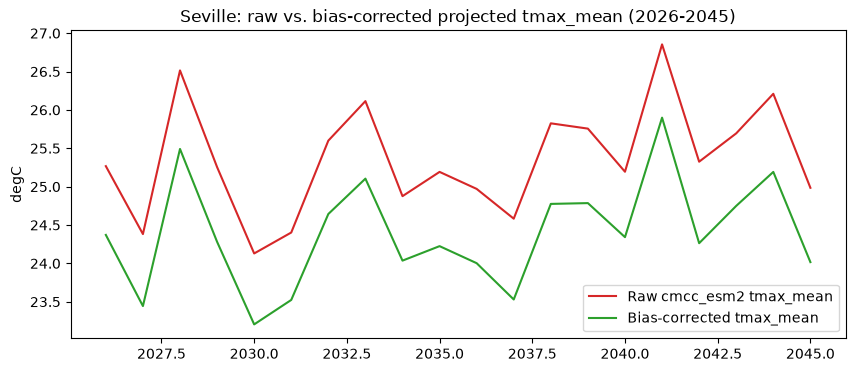

Mean shift from correction: -0.96 degC

Per-month bias (model historical vs. ERA5, 1990-2014) for tmean_c:
       mean_bias_hist_vs_obs
month                       
1                      -0.30
2                      -0.55
3                      -0.23
4                       0.86
5                       1.19
6                       1.34
7                       3.04
8                       3.35
9                       2.26
10                      0.62
11                     -0.18
12                     -0.42


In [14]:
raw_annual_tmax = daily.groupby("year")["tmax_c"].mean()
corrected_annual_tmax = corrected.groupby("year")["tmax_c"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(raw_annual_tmax.index, raw_annual_tmax.values, label="Raw cmcc_esm2 tmax_mean", color="tab:red")
ax.plot(corrected_annual_tmax.index, corrected_annual_tmax.values,
        label="Bias-corrected tmax_mean", color="tab:green")
ax.set_ylabel("degC")
ax.set_title("Seville: raw vs. bias-corrected projected tmax_mean (2026-2045)")
ax.legend()
plt.show()

print(f"Mean shift from correction: {(corrected_annual_tmax - raw_annual_tmax).mean():+.2f} degC")

print("\nPer-month bias (model historical vs. ERA5, 1990-2014) for tmean_c:")
print(bc_diag_df.loc[bc_diag_df["variable"] == "tmean_c", ["month", "mean_bias_hist_vs_obs"]]
      .set_index("month").round(2))

## 13. Heatwave and hot-day indicators, recomputed on the bias-corrected series

Section 7's logic exactly, applied to `corrected` instead of raw `daily` -- same fixed thresholds
(`THRESH`, tropical-night 20 degC, heat-index 35 degC) and the same fixed ERA5 1990-2020 P90-by-doy
dict from Section 6 (still not refit -- the threshold stays anchored to the historical reference
regardless of which projection series it's being applied to).

In [15]:
d_corrected = corrected.copy()
d_corrected["doy"] = d_corrected.index.dayofyear
d_corrected["tmax_p90"] = d_corrected["doy"].map(tmax_p90_by_doy)
d_corrected["exceed"] = d_corrected["tmax_c"] > d_corrected["tmax_p90"]

grp_c = (d_corrected["exceed"] != d_corrected["exceed"].shift()).cumsum()
runs_c = (d_corrected[d_corrected["exceed"]]
          .groupby(grp_c[d_corrected["exceed"]])
          .agg(start=("tmax_c", lambda s: s.index.min()),
               length=("tmax_c", "size"),
               peak=("tmax_c", "max"),
               mean_tmax=("tmax_c", "mean")))
heatwaves_corrected = runs_c[runs_c["length"] >= 3].reset_index(drop=True)
heatwaves_corrected["year"] = pd.to_datetime(heatwaves_corrected["start"]).dt.year
heatwaves_corrected.to_csv(OUT / "seville_projection_heatwave_events_biascorrected.csv", index=False)

hot_corrected = pd.DataFrame({
    f"days tmax>={t} C": d_corrected.groupby("year")["tmax_c"].apply(lambda s, t=t: (s >= t).sum())
    for t in THRESH
})
hot_corrected["tropical nights tmin>=20 C"] = (
    d_corrected.groupby("year")["tmin_c"].apply(lambda s: int((s >= 20).sum())))
hot_corrected["days heat index>=35 C"] = (
    d_corrected.groupby("year")["heat_index_c"].apply(lambda s: int((s >= 35).sum())))

hw_year_corrected = heatwaves_corrected.groupby("year").agg(
    heatwaves=("length", "size"),
    **{"heatwave days": ("length", "sum"), "longest (days)": ("length", "max")},
)

print(f"RAW:       {len(heatwaves):3d} heatwave events, {heatwaves['year'].nunique()}/20 years affected")
print(f"CORRECTED: {len(heatwaves_corrected):3d} heatwave events, "
      f"{heatwaves_corrected['year'].nunique()}/20 years affected")

hot_indicator_compare = pd.DataFrame({
    "raw_annual_mean": hot.mean(),
    "corrected_annual_mean": hot_corrected.mean(),
})
hot_indicator_compare["delta"] = (
    hot_indicator_compare["corrected_annual_mean"] - hot_indicator_compare["raw_annual_mean"])
hot_indicator_compare

RAW:       299 heatwave events, 20/20 years affected
CORRECTED: 195 heatwave events, 20/20 years affected


,raw_annual_mean,corrected_annual_mean,delta
days tmax>=30 C,124.80,107.25,-17.55
days tmax>=33 C,90.80,67.95,-22.85
days tmax>=35 C,67.15,43.95,-23.20
days tmax>=37 C,42.25,20.75,-21.50
days tmax>=40 C,11.45,2.35,-9.10
tropical nights tmin>=20 C,131.30,89.30,-42.00
days heat index>=35 C,2.50,1.20,-1.30


## 14. Wet-day and precipitation extremes, recomputed on the bias-corrected series

Section 8's logic exactly, applied to `corrected["precip_mm_day"]` (multiplicatively corrected in
Section 12) instead of the raw value.

In [16]:
d_corrected["is_wet"] = d_corrected["precip_mm_day"] >= WET

wetstats_corrected = d_corrected.groupby("year").apply(lambda g: pd.Series({
    "wet days": int(g["is_wet"].sum()),
    "mean intensity (mm/wet day)": g.loc[g["is_wet"], "precip_mm_day"].mean(),
    "max 1-day (mm)": g["precip_mm_day"].max(),
    "P95 wet-day (mm)": g.loc[g["is_wet"], "precip_mm_day"].quantile(0.95),
    "longest dry spell (days)": max_dry_run(g["is_wet"]),
}), include_groups=False)

wet_compare = pd.DataFrame({
    "raw_annual_mean": wetstats.mean(),
    "corrected_annual_mean": wetstats_corrected.mean(),
})
wet_compare["delta"] = wet_compare["corrected_annual_mean"] - wet_compare["raw_annual_mean"]
wet_compare

,raw_annual_mean,corrected_annual_mean,delta
wet days,46.000000,49.600000,3.600000
mean intensity (mm/wet day),4.829730,8.477132,3.647401
max 1-day (mm),21.490156,48.635692,27.145536
P95 wet-day (mm),13.428695,28.105977,14.677282
longest dry spell (days),92.000000,114.400000,22.400000


## 15. Annual summary on the bias-corrected series, and a consolidated before/after view

Section 9's logic exactly, joining Sections 13-14's corrected indicators into the same shape as
`annual_summary`. The comparison table and plot below are the main "so we can see the results"
deliverable -- key indicator means averaged across all 20 projected years, raw vs. corrected.

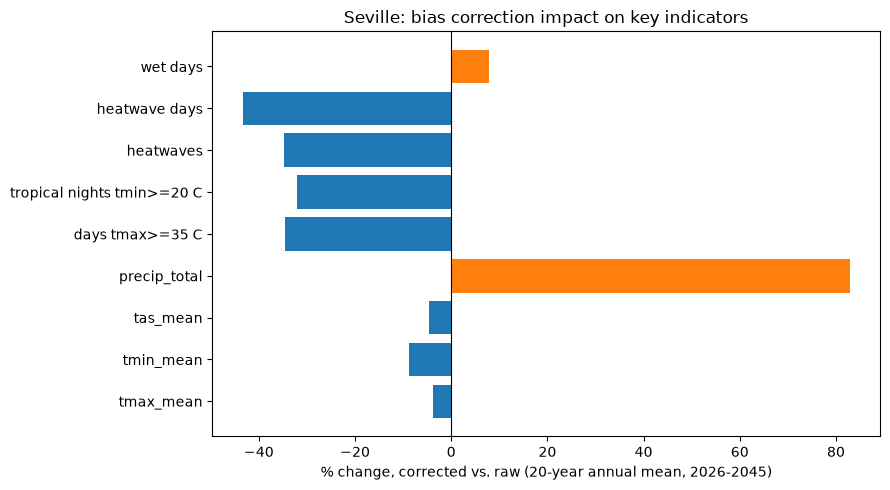

,raw,corrected,delta,pct_change
tmax_mean,25.36,24.39,-0.96,-3.80
tmin_mean,16.48,15.04,-1.45,-8.77
tas_mean,20.82,19.86,-0.95,-4.58
precip_total,248.15,453.71,205.57,82.84
days tmax>=35 C,67.15,43.95,-23.20,-34.55
tropical nights tmin>=20 C,131.30,89.30,-42.00,-31.99
heatwaves,14.95,9.75,-5.20,-34.78
heatwave days,94.95,53.80,-41.15,-43.34
wet days,46.00,49.60,3.60,7.83


In [17]:
annual_corrected = pd.DataFrame({
    "tas_mean": d_corrected.groupby("year")["tmean_c"].mean(),
    "rh_mean": d_corrected.groupby("year")["rh_mean_percent"].mean(),
    "heat_index_mean": d_corrected.groupby("year")["heat_index_c"].mean(),
    "wind_mean": d_corrected.groupby("year")["wind_avg"].mean(),
    "tas_p95": d_corrected.groupby("year")["tmean_c"].quantile(0.95),
    "tas_p05": d_corrected.groupby("year")["tmean_c"].quantile(0.05),
    "tmax_mean": d_corrected.groupby("year")["tmax_c"].mean(),
    "tmin_mean": d_corrected.groupby("year")["tmin_c"].mean(),
    "precip_total": d_corrected.groupby("year")["precip_mm_day"].sum(),
})

annual_summary_corrected = (annual_corrected
                             .join(hot_corrected, how="left")
                             .join(hw_year_corrected, how="left")
                             .join(wetstats_corrected, how="left"))
for col in ["heatwaves", "heatwave days", "longest (days)"]:
    annual_summary_corrected[col] = annual_summary_corrected[col].fillna(0).astype(int)

annual_summary_corrected.to_csv(OUT / "seville_projection_annual_summary_biascorrected.csv")

compare_cols = ["tmax_mean", "tmin_mean", "tas_mean", "precip_total",
                "days tmax>=35 C", "tropical nights tmin>=20 C",
                "heatwaves", "heatwave days", "wet days"]
before_after = pd.DataFrame({
    "raw": annual_summary[compare_cols].mean(),
    "corrected": annual_summary_corrected[compare_cols].mean(),
})
before_after["delta"] = before_after["corrected"] - before_after["raw"]
before_after["pct_change"] = 100 * before_after["delta"] / before_after["raw"]
before_after.to_csv(OUT / "seville_projection_before_after_bias_correction_summary.csv")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["tab:blue" if v < 0 else "tab:orange" for v in before_after["pct_change"]]
ax.barh(before_after.index, before_after["pct_change"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("% change, corrected vs. raw (20-year annual mean, 2026-2045)")
ax.set_title("Seville: bias correction impact on key indicators")
plt.tight_layout()
plt.show()

before_after.round(2)

## 16. Trend within the projection period, raw vs. bias-corrected

Section 10's `trend_table()` re-applied to `annual_summary_corrected`. A roughly constant
per-month bias correction (Section 12) shifts the *level* of each series without necessarily
changing its *slope* much -- so don't expect this comparison to overturn Section 10's "not
statistically significant at 20 years, single model/scenario" conclusion; it's here to confirm
that explicitly rather than leave it assumed.

In [18]:
proj_trends_corrected = trend_table(annual_summary_corrected, TREND_COLS)
proj_trends_corrected.to_csv(OUT / "seville_projection_trends_biascorrected.csv")

trend_compare = pd.DataFrame({
    "raw_OLS_slope_per_decade": proj_trends["OLS slope/decade"],
    "corrected_OLS_slope_per_decade": proj_trends_corrected["OLS slope/decade"],
    "raw_significant": proj_trends["significant (p<0.05)"],
    "corrected_significant": proj_trends_corrected["significant (p<0.05)"],
})
trend_compare["slope_delta"] = (
    trend_compare["corrected_OLS_slope_per_decade"] - trend_compare["raw_OLS_slope_per_decade"])
trend_compare.round(3)

,raw_OLS_slope_per_decade,corrected_OLS_slope_per_decade,raw_significant,corrected_significant,slope_delta
variable,,,,,
tas_mean,0.382,0.341,False,False,-0.041
heat_index_mean,0.447,0.450,False,False,0.003
tas_p95,0.588,0.564,False,False,-0.024
tmax_mean,0.376,0.347,False,False,-0.028
tmin_mean,0.387,0.409,False,False,0.022
precip_total,1.536,-2.318,False,False,-3.853


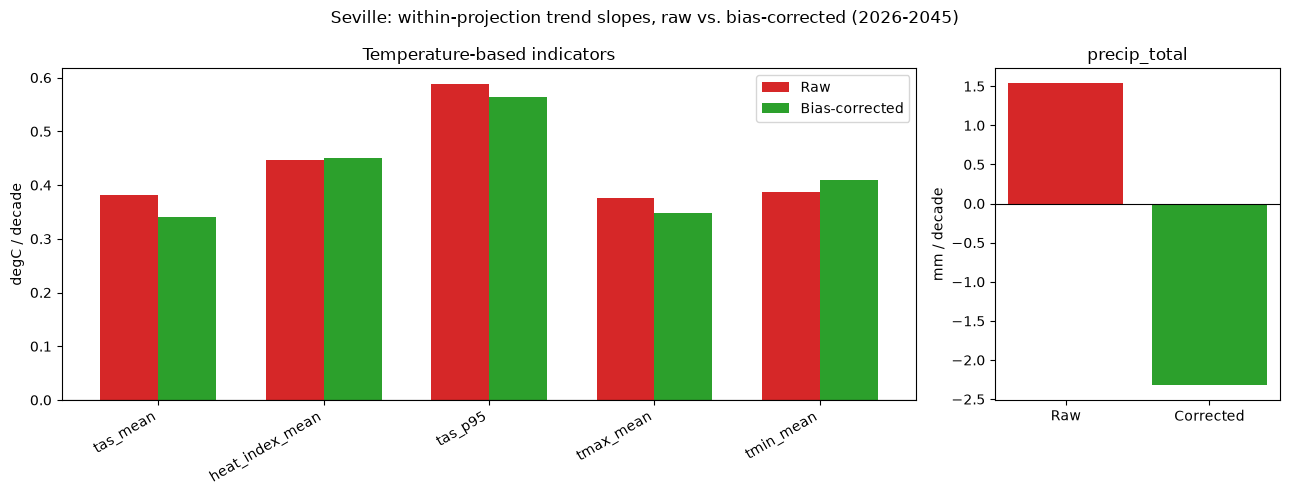

None of these slopes are statistically significant at p<0.05, raw or corrected (see the significance columns in the table above) -- read this chart as 'does correction change the estimated direction/magnitude', not as 'which of these trends is real'.


In [19]:
temp_vars = ["tas_mean", "heat_index_mean", "tas_p95", "tmax_mean", "tmin_mean"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [3, 1]})

x = np.arange(len(temp_vars))
width = 0.35
axes[0].bar(x - width / 2, trend_compare.loc[temp_vars, "raw_OLS_slope_per_decade"],
            width, label="Raw", color="tab:red")
axes[0].bar(x + width / 2, trend_compare.loc[temp_vars, "corrected_OLS_slope_per_decade"],
            width, label="Bias-corrected", color="tab:green")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(temp_vars, rotation=30, ha="right")
axes[0].set_ylabel("degC / decade")
axes[0].set_title("Temperature-based indicators")
axes[0].legend()

axes[1].bar(["Raw"], [trend_compare.loc["precip_total", "raw_OLS_slope_per_decade"]], color="tab:red")
axes[1].bar(["Corrected"], [trend_compare.loc["precip_total", "corrected_OLS_slope_per_decade"]],
            color="tab:green")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("mm / decade")
axes[1].set_title("precip_total")

fig.suptitle("Seville: within-projection trend slopes, raw vs. bias-corrected (2026-2045)")
plt.tight_layout()
plt.show()

print("None of these slopes are statistically significant at p<0.05, raw or corrected (see the "
      "significance columns in the table above) -- read this chart as 'does correction change the "
      "estimated direction/magnitude', not as 'which of these trends is real'.")

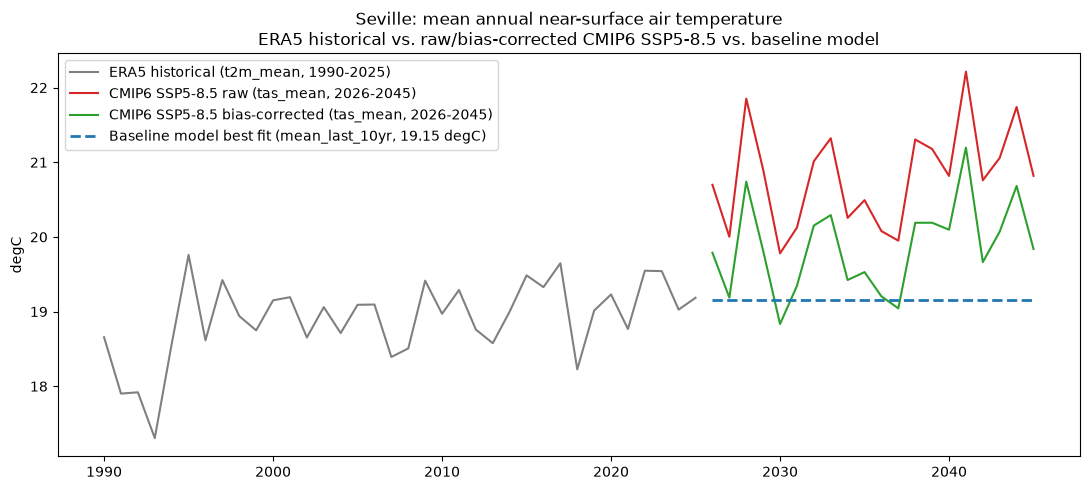

In [20]:
# Baseline-model comparison (see baseline_models_results/baseline_models.ipynb, Section 3): for
# Seville's t2m_mean, "mean_last_10yr" -- a flat mean of the most recent 10 training years, not a
# fitted trend -- beat naive_full_mean, ols_full_history, and ols_last_15yr on held-out MAE (0.309
# vs. 0.388/0.415/0.410 degC over a 2018-2025 test split). Recomputed here on the full 2016-2025
# record (rather than that notebook's 1990-2017 training-only slice) and held flat across the
# projection period, consistent with that notebook's framing of it as the "if current conditions
# persist" baseline -- not an extrapolated warming trend, since no trend candidate beat this one.
baseline_last10yr_mean = era5_annual["t2m_mean"].iloc[-10:].mean()

tas_mean_compare = pd.DataFrame({
    "era5_historical": era5_annual["t2m_mean"],
    "cmip6_raw": annual_summary["tas_mean"],
    "cmip6_biascorrected": annual_summary_corrected["tas_mean"],
})
tas_mean_compare["baseline_mean_last10yr"] = np.where(
    tas_mean_compare.index.isin(annual_summary.index), baseline_last10yr_mean, np.nan)
tas_mean_compare.to_csv(OUT / "seville_tas_mean_era5_vs_cmip6_raw_vs_corrected.csv")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tas_mean_compare.index, tas_mean_compare["era5_historical"],
        label="ERA5 historical (t2m_mean, 1990-2025)", color="gray")
ax.plot(tas_mean_compare.index, tas_mean_compare["cmip6_raw"],
        label="CMIP6 SSP5-8.5 raw (tas_mean, 2026-2045)", color="tab:red")
ax.plot(tas_mean_compare.index, tas_mean_compare["cmip6_biascorrected"],
        label="CMIP6 SSP5-8.5 bias-corrected (tas_mean, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, tas_mean_compare.loc[annual_summary.index, "baseline_mean_last10yr"],
        "--", linewidth=2, color="tab:blue",
        label=f"Baseline model best fit (mean_last_10yr, {baseline_last10yr_mean:.2f} degC)")
ax.set_ylabel("degC")
ax.set_title("Seville: mean annual near-surface air temperature\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP5-8.5 vs. baseline model")
ax.legend()
plt.tight_layout()
plt.show()


naive_full_mean (1990-2025):        23.366 degC
ols_last_20yr, extrapolated (2045): 24.232 degC


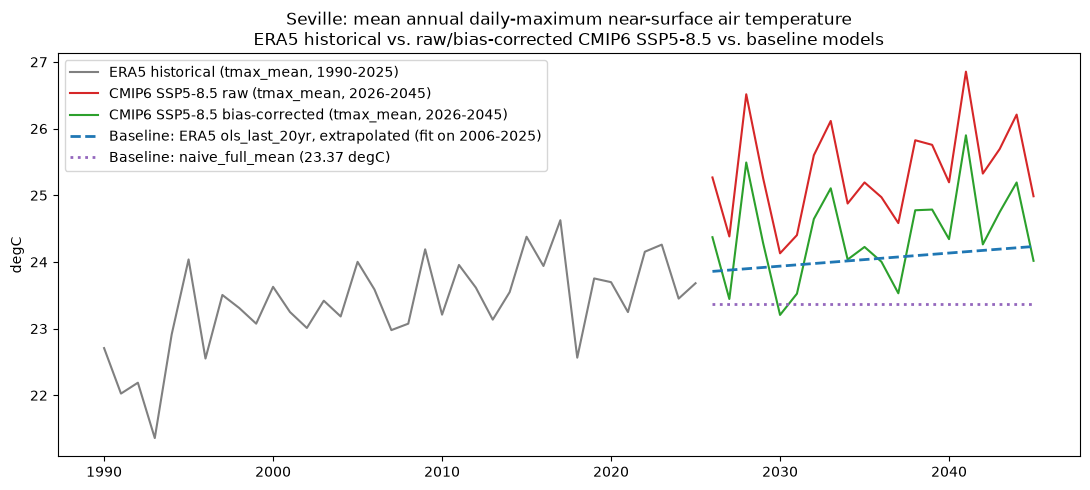

In [21]:
# Same comparison, for tmax_mean. Two baselines shown against the ERA5/CMIP6 series:
# "ols_last_20yr" reuses Section 11's own ERA5 trend extrapolation (`era5_extrapolated`, fit on
# 2006-2025, already computed above) rather than the flat mean_last_10yr candidate used in the
# t2m_mean plot -- for tmax_mean specifically, Section 11 already established this as the
# baseline-vs-projection comparison of interest, so it's reused here rather than duplicated.
# "naive_full_mean" (baseline_models.ipynb's runner-up by MAE) is kept alongside it: full-history
# mean (1990-2025) vs. the 2006-2025 trend extrapolated to 2026-2045 differ enough to be worth
# seeing on the same axes, not just the two CMIP6 series against each other.
baseline_fullmean_tmax_mean = era5_annual["tmax_mean"].mean()
print(f"naive_full_mean (1990-2025):        {baseline_fullmean_tmax_mean:.3f} degC")
print(f"ols_last_20yr, extrapolated (2045): {era5_extrapolated[-1]:.3f} degC")

tmax_mean_compare = pd.DataFrame({
    "era5_historical": era5_annual["tmax_mean"],
    "cmip6_raw": annual_summary["tmax_mean"],
    "cmip6_biascorrected": annual_summary_corrected["tmax_mean"],
})
tmax_mean_compare["baseline_ols_last20yr"] = pd.Series(
    era5_extrapolated, index=annual_summary.index).reindex(tmax_mean_compare.index)
tmax_mean_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_fullmean_tmax_mean, index=annual_summary.index).reindex(tmax_mean_compare.index)
tmax_mean_compare.to_csv(OUT / "seville_tmax_mean_era5_vs_cmip6_raw_vs_corrected.csv")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tmax_mean_compare.index, tmax_mean_compare["era5_historical"],
        label="ERA5 historical (tmax_mean, 1990-2025)", color="gray")
ax.plot(tmax_mean_compare.index, tmax_mean_compare["cmip6_raw"],
        label="CMIP6 SSP5-8.5 raw (tmax_mean, 2026-2045)", color="tab:red")
ax.plot(tmax_mean_compare.index, tmax_mean_compare["cmip6_biascorrected"],
        label="CMIP6 SSP5-8.5 bias-corrected (tmax_mean, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, tmax_mean_compare.loc[annual_summary.index, "baseline_ols_last20yr"],
        "--", linewidth=2, color="tab:blue",
        label="Baseline: ERA5 ols_last_20yr, extrapolated (fit on 2006-2025)")
ax.plot(annual_summary.index, tmax_mean_compare.loc[annual_summary.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean ({baseline_fullmean_tmax_mean:.2f} degC)")
ax.set_ylabel("degC")
ax.set_title("Seville: mean annual daily-maximum near-surface air temperature\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP5-8.5 vs. baseline models")
ax.legend()
plt.tight_layout()
plt.show()


In [22]:
# How much warming does the historical trend alone predict, vs. what the bias-corrected
# projection actually shows? Reuses `lr` (the ols_last_20yr fit from Section 11, ERA5 2006-2025)
# and `trend_compare`/`proj_trends_corrected` (Section 16's own raw-vs-corrected trend table) --
# no new fitting here, just reading off what's already been computed above.
proj = tmax_mean_compare.dropna(subset=["cmip6_biascorrected"])
gap = proj["cmip6_biascorrected"] - proj["baseline_ols_last20yr"]

baseline_warming = proj["baseline_ols_last20yr"].iloc[-1] - proj["baseline_ols_last20yr"].iloc[0]
baseline_slope_decade = lr.slope * 10
corrected_slope_decade = trend_compare.loc["tmax_mean", "corrected_OLS_slope_per_decade"]
corrected_p = proj_trends_corrected.loc["tmax_mean", "OLS p-value"]

print(f"ols_last_20yr historical-trend extrapolation: {proj['baseline_ols_last20yr'].iloc[0]:.2f} degC (2026) "
      f"-> {proj['baseline_ols_last20yr'].iloc[-1]:.2f} degC (2045), {baseline_warming:+.2f} degC "
      f"({baseline_slope_decade:.2f} degC/decade)")
print(f"Bias-corrected CMIP6 SSP5-8.5 vs. that extrapolation: mean gap = {gap.mean():+.2f} degC "
      f"(ranges {gap.min():+.2f} to {gap.max():+.2f} degC across individual years, 2026-2045)")
print(f"Bias-corrected CMIP6's own within-period trend: {corrected_slope_decade:.2f} degC/decade "
      f"(p={corrected_p:.2f}, {'significant' if corrected_p < 0.05 else 'not significant'} at p<0.05)")


ols_last_20yr historical-trend extrapolation: 23.86 degC (2026) -> 24.23 degC (2045), +0.37 degC (0.20 degC/decade)
Bias-corrected CMIP6 SSP5-8.5 vs. that extrapolation: mean gap = +0.35 degC (ranges -0.73 to +1.75 degC across individual years, 2026-2045)
Bias-corrected CMIP6's own within-period trend: 0.35 degC/decade (p=0.21, not significant at p<0.05)


### Reading the gap: historical trend vs. bias-corrected projection

Comparing the `ols_last_20yr` historical-trend extrapolation (fit on ERA5 2006-2025) against the
bias-corrected CMIP6 SSP5-8.5 series above:

- **Historical trend alone** implies about **+0.37 degC of warming over 2026-2045** (~0.20 degC/decade)
  if the last 20 years of ERA5 observations simply continue in a straight line.
- **The bias-corrected projection runs warmer than that** -- on average about **+0.35 degC above**
  the historical-trend extrapolation for any given year -- and its own within-period trend
  (~0.35 degC/decade) is roughly 1.8x steeper than the historical rate.
- **Two caveats keep this from being a clean "acceleration confirmed" finding:**
  1. The year-by-year gap is noisy, not a steady offset -- it swings across individual years rather
     than tracking a fixed amount above the historical line.
  2. The corrected series' own trend is **not statistically significant** (p > 0.05, see the Section 16
     trend table above) -- unsurprising with only 20 years of data from a single model/scenario run.

**Net read:** bias correction does not erase the gap between "if the last 20 years just continue"
and "what SSP5-8.5 actually shows" -- there is a real, positive average offset -- but the data here
isn't strong enough on its own to say the *rate* of warming is confirmed to accelerate beyond the
historical trend, only that the projection consistently runs warmer than simple extrapolation would
predict.


### Same comparison, for `precip_total`

`precip_total` (Seville) was never baseline-tested elsewhere in the project -- only Larissa's
`precip_scaled` was tested in `baseline_models_results/baseline_models.ipynb`, and
`Climate_Indicators_Modeling.ipynb` covers `tmax_mean`/`min_spi3`/`longest_high_run`, not
`precip_total`. So unlike the `tmax_mean` baseline above (which reused an existing recommended
model), the cell below first runs the same held-out-MAE model-selection methodology inline --
naive_full_mean vs. four OLS recency windows, 2018-2025 held out -- to find which one actually
wins here, then plots that winner alongside naive_full_mean and the raw/corrected CMIP6 series.


Held-out MAE (test 2018-2025), ERA5 precip_scaled:
ols_last_15yr       109.4
ols_last_20yr       119.4
naive_full_mean     122.0
ols_full_history    136.6
ols_last_10yr       245.7
Best by MAE: ols_last_15yr


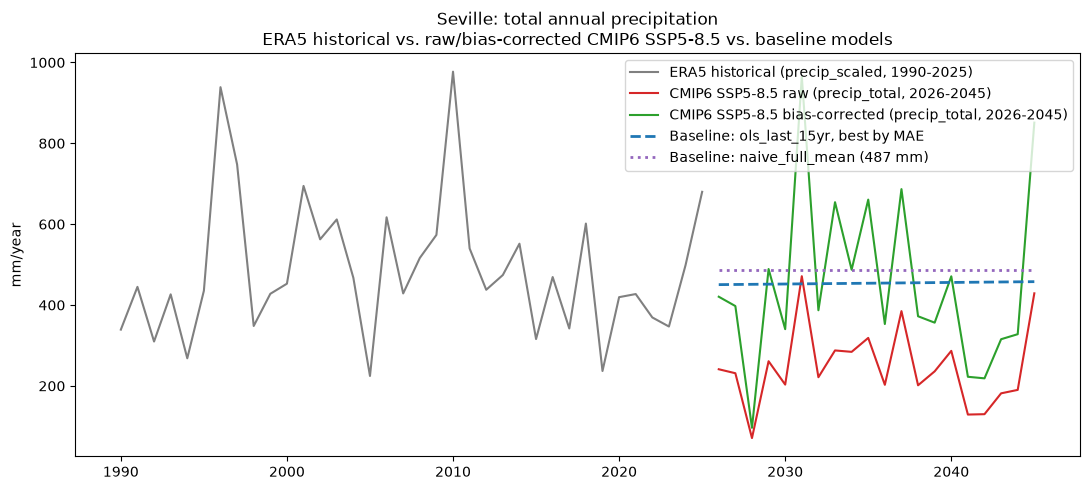

In [23]:
# Model selection: replicate baseline_models.ipynb's own methodology (8-year held-out test,
# naive_full_mean vs. OLS full-history/20yr/15yr/10yr recency windows, ranked by MAE) on ERA5
# precip_scaled, since precip_total has no existing "recommended model" to pull in.
precip_years = era5_annual.index.values.astype(float)
precip_y = era5_annual["precip_scaled"].values.astype(float)

n_test = 8
split_yr = era5_annual.index[-n_test]
train_mask = era5_annual.index < split_yr
yrs_tr, yrs_te = precip_years[train_mask], precip_years[~train_mask]
y_tr, y_te = precip_y[train_mask], precip_y[~train_mask]

def mae(pred):
    return float(np.mean(np.abs(y_te - pred)))

OLS_WINDOWS_PRECIP = {"ols_full_history": None, "ols_last_20yr": 20, "ols_last_15yr": 15, "ols_last_10yr": 10}
candidate_mae = {"naive_full_mean": mae(np.full_like(y_te, y_tr.mean()))}
for name, window in OLS_WINDOWS_PRECIP.items():
    yt = yrs_tr[-window:] if window else yrs_tr
    yy = y_tr[-window:] if window else y_tr
    lr_p = stats.linregress(yt, yy)
    candidate_mae[name] = mae(lr_p.intercept + lr_p.slope * yrs_te)

mae_table = pd.Series(candidate_mae).sort_values()
best_precip_model = mae_table.index[0]
print(f"Held-out MAE (test {int(yrs_te.min())}-{int(yrs_te.max())}), ERA5 precip_scaled:")
print(mae_table.round(1).to_string())
print(f"Best by MAE: {best_precip_model}")

# Refit the winner on the full 1990-2025 record (not just the train slice) for the forward
# extrapolation -- same "today's best full-data fit" logic as tmax_mean's ols_last_20yr baseline
# in Section 11/16 above.
best_window = OLS_WINDOWS_PRECIP.get(best_precip_model)
if best_window:
    yt_full, yy_full = precip_years[-best_window:], precip_y[-best_window:]
else:
    yt_full, yy_full = precip_years, precip_y
lr_precip_best = stats.linregress(yt_full, yy_full)

proj_years_p = annual_summary.index.values.astype(float)
precip_ols_extrapolated = lr_precip_best.intercept + lr_precip_best.slope * proj_years_p
baseline_precip_naive_full = era5_annual["precip_scaled"].mean()

precip_total_compare = pd.DataFrame({
    "era5_historical": era5_annual["precip_scaled"],
    "cmip6_raw": annual_summary["precip_total"],
    "cmip6_biascorrected": annual_summary_corrected["precip_total"],
})
precip_total_compare["baseline_ols_best"] = pd.Series(
    precip_ols_extrapolated, index=annual_summary.index).reindex(precip_total_compare.index)
precip_total_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_precip_naive_full, index=annual_summary.index).reindex(precip_total_compare.index)
precip_total_compare.to_csv(OUT / "seville_precip_total_era5_vs_cmip6_raw_vs_corrected.csv")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(precip_total_compare.index, precip_total_compare["era5_historical"],
        label="ERA5 historical (precip_scaled, 1990-2025)", color="gray")
ax.plot(precip_total_compare.index, precip_total_compare["cmip6_raw"],
        label="CMIP6 SSP5-8.5 raw (precip_total, 2026-2045)", color="tab:red")
ax.plot(precip_total_compare.index, precip_total_compare["cmip6_biascorrected"],
        label="CMIP6 SSP5-8.5 bias-corrected (precip_total, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, precip_total_compare.loc[annual_summary.index, "baseline_ols_best"],
        "--", linewidth=2, color="tab:blue",
        label=f"Baseline: {best_precip_model}, best by MAE")
ax.plot(annual_summary.index, precip_total_compare.loc[annual_summary.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean ({baseline_precip_naive_full:.0f} mm)")
ax.set_ylabel("mm/year")
ax.set_title("Seville: total annual precipitation\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP5-8.5 vs. baseline models")
ax.legend()
plt.tight_layout()
plt.show()


### Same comparison, for `min_spi3` (annual drought depth)

Historical and projected series both come from the dedicated SPI-3 notebooks rather than being
recomputed here: `Calculating_SPI_for_Seville.ipynb` (ERA5 1990-2025) and
`Calculating_SPI_for_Seville_Projection.ipynb` (CMIP6 2026-2045, raw and bias-corrected), the latter
scored against that same fixed ERA5 1990-2020 gamma distribution -- never refit on the projection,
per `fixed_reference_period_principle.md`.

**Baseline model differs from `tmax_mean`'s.** `Climate_Indicators_Modeling.ipynb` Sections 8-9 tried
31 candidates across three different modeling approaches for `min_spi3` and found none reliably beat
`naive_full_mean` (flat historical trend, p=0.454) -- unlike `tmax_mean`, where `ols_last_20yr` won
robustly. That notebook's Section 10 explicitly recommends against extrapolating a trend here: "there's
no defensible historical trend to extrapolate... doing so anyway would mean presenting extrapolated
noise as if it were a real forecast." So the baseline plotted below is the flat `naive_full_mean`, not
a sloped fit -- following that guidance rather than defaulting to a trend line for consistency's sake.

**One caveat carried over from the projection SPI-3 notebook:** its Section 6 found the bias
correction's multiplicative amplification (concentrated in September/October/January) pushes several
months into spuriously "severely wet" SPI-3 readings. Since `min_spi3` takes the *driest* window each
year, that effect mostly doesn't inflate this particular series -- but in years where the driest window
happens to fall near an amplified month, the bias-corrected `min_spi3` could read less severe (closer
to normal) than it otherwise would. Worth keeping in mind if any single corrected year here looks
unexpectedly mild.


naive_full_mean, ERA5 1990-2025 (recommended baseline per Climate_Indicators_Modeling.ipynb): -1.444
Bias-corrected projected min_spi3 vs. naive_full_mean baseline: mean gap = -0.84 (range -2.77 to +0.51 across 2026-2045)


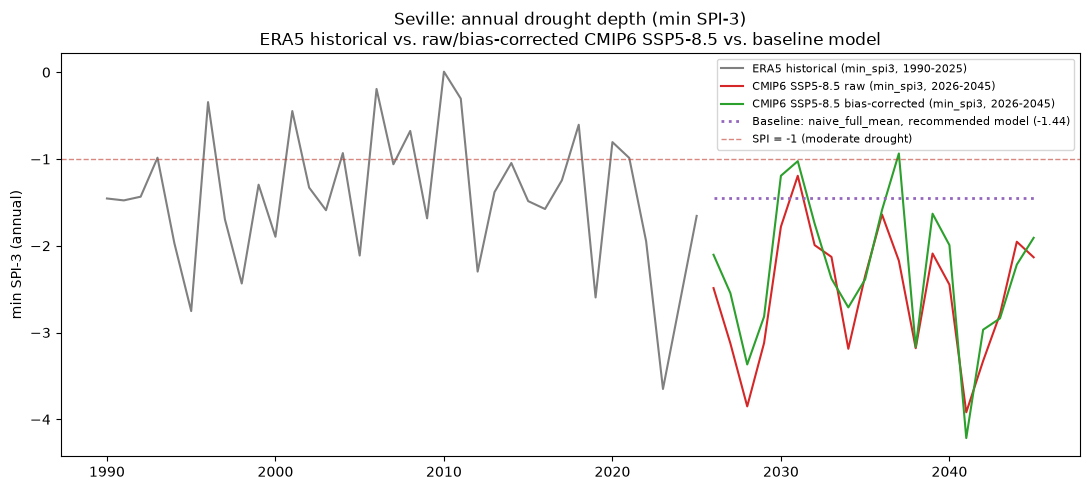

In [24]:
# min_spi3 comparison, same Section 16 pattern as tas_mean/tmax_mean/precip_total above.
era5_spi3 = pd.read_csv("../../Historical/eda_outputs/seville/seville_spi3_annual.csv", index_col="year")["min_spi3"]
proj_spi3 = pd.read_csv("../eda_outputs/seville/seville_projection_spi3_annual.csv",
                         index_col="year")

baseline_spi3_naive_full = era5_spi3.mean()
print(f"naive_full_mean, ERA5 1990-2025 (recommended baseline per Climate_Indicators_Modeling.ipynb): "
      f"{baseline_spi3_naive_full:.3f}")

min_spi3_compare = pd.DataFrame({
    "era5_historical": era5_spi3,
    "cmip6_raw": proj_spi3["min_spi3_raw"],
    "cmip6_biascorrected": proj_spi3["min_spi3_corrected"],
})
min_spi3_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_spi3_naive_full, index=proj_spi3.index).reindex(min_spi3_compare.index)
min_spi3_compare.to_csv(OUT / "seville_min_spi3_era5_vs_cmip6_raw_vs_corrected.csv")

gap = min_spi3_compare.loc[proj_spi3.index, "cmip6_biascorrected"] - baseline_spi3_naive_full
print(f"Bias-corrected projected min_spi3 vs. naive_full_mean baseline: mean gap = {gap.mean():+.2f} "
      f"(range {gap.min():+.2f} to {gap.max():+.2f} across 2026-2045)")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(min_spi3_compare.index, min_spi3_compare["era5_historical"],
        label="ERA5 historical (min_spi3, 1990-2025)", color="gray")
ax.plot(min_spi3_compare.index, min_spi3_compare["cmip6_raw"],
        label="CMIP6 SSP5-8.5 raw (min_spi3, 2026-2045)", color="tab:red")
ax.plot(min_spi3_compare.index, min_spi3_compare["cmip6_biascorrected"],
        label="CMIP6 SSP5-8.5 bias-corrected (min_spi3, 2026-2045)", color="tab:green")
ax.plot(proj_spi3.index, min_spi3_compare.loc[proj_spi3.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean, recommended model ({baseline_spi3_naive_full:.2f})")
ax.axhline(-1, color="#c0392b", linestyle="--", linewidth=1, alpha=0.6, label="SPI = -1 (moderate drought)")
ax.set_ylabel("min SPI-3 (annual)")
ax.set_title("Seville: annual drought depth (min SPI-3)\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP5-8.5 vs. baseline model")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### `t2m_mean`, revisited with the Climate_Indicators_Modeling.ipynb Section 13 recommended model

The `tas_mean` comparison earlier in this section used `mean_last_10yr` (a flat baseline from
`baseline_models_results/baseline_models.ipynb`'s original single-split test). `Climate_Indicators_
Modeling.ipynb` Section 13 has since run the full walk-forward-CV treatment on `t2m_mean` specifically
and found something more decisive: both the single split *and* the CV-averaged view agree a regression
beats naive (9.6% CV improvement, `ols_full_history`) -- a cleaner, more robust result than `tmax_mean`
got at the equivalent stage. Same reasoning as the earlier `tmax_mean` swap from a flat baseline to
`ols_last_20yr`: use the more rigorous recommended model rather than the earlier single-split pick.


ols_full_history extrapolation: 19.32 degC (2026) -> 19.75 degC (2045)
Bias-corrected CMIP6 vs. that extrapolation: mean gap = +0.33 degC (range -0.58 to +1.54)


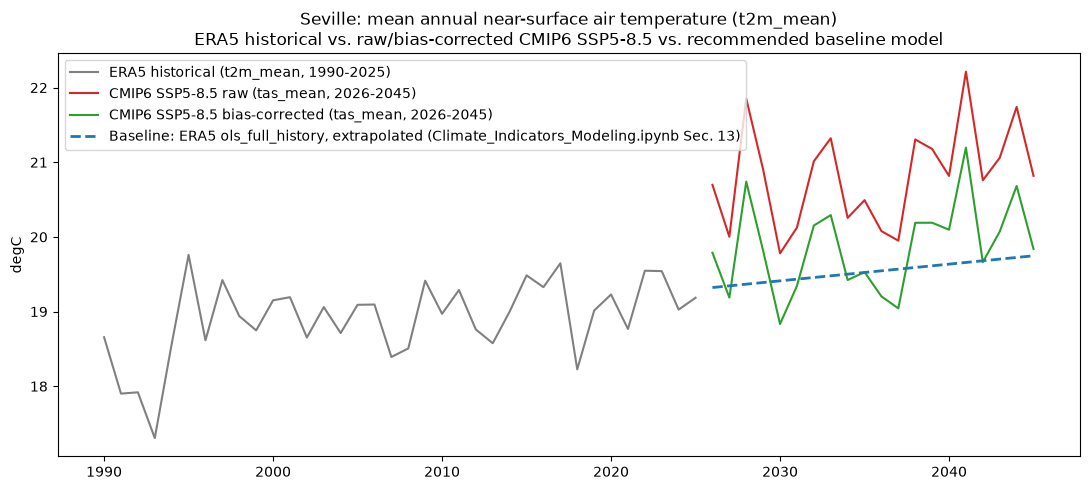

In [25]:
era5_fwi_annual = pd.read_csv("../../Historical/eda_outputs/seville/seville_fwi_annual.csv", index_col="year")

last_full_t2m = era5_annual["t2m_mean"]
lr_t2m = stats.linregress(last_full_t2m.index.values.astype(float), last_full_t2m.values.astype(float))
t2m_ols_extrapolated = lr_t2m.intercept + lr_t2m.slope * proj_years

t2m_mean_compare = pd.DataFrame({
    "era5_historical": era5_annual["t2m_mean"],
    "cmip6_raw": annual_summary["tas_mean"],
    "cmip6_biascorrected": annual_summary_corrected["tas_mean"],
})
t2m_mean_compare["baseline_ols_full_history"] = pd.Series(
    t2m_ols_extrapolated, index=annual_summary.index).reindex(t2m_mean_compare.index)
t2m_mean_compare.to_csv(OUT / "seville_t2m_mean_era5_vs_cmip6_raw_vs_corrected_v2.csv")

print(f"ols_full_history extrapolation: {t2m_mean_compare.loc[2026, 'baseline_ols_full_history']:.2f} degC (2026) "
      f"-> {t2m_mean_compare.loc[2045, 'baseline_ols_full_history']:.2f} degC (2045)")
gap_t2m = t2m_mean_compare.loc[annual_summary.index, "cmip6_biascorrected"] - t2m_mean_compare.loc[annual_summary.index, "baseline_ols_full_history"]
print(f"Bias-corrected CMIP6 vs. that extrapolation: mean gap = {gap_t2m.mean():+.2f} degC "
      f"(range {gap_t2m.min():+.2f} to {gap_t2m.max():+.2f})")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(t2m_mean_compare.index, t2m_mean_compare["era5_historical"],
        label="ERA5 historical (t2m_mean, 1990-2025)", color="gray")
ax.plot(t2m_mean_compare.index, t2m_mean_compare["cmip6_raw"],
        label="CMIP6 SSP5-8.5 raw (tas_mean, 2026-2045)", color="tab:red")
ax.plot(t2m_mean_compare.index, t2m_mean_compare["cmip6_biascorrected"],
        label="CMIP6 SSP5-8.5 bias-corrected (tas_mean, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, t2m_mean_compare.loc[annual_summary.index, "baseline_ols_full_history"],
        "--", linewidth=2, color="tab:blue",
        label="Baseline: ERA5 ols_full_history, extrapolated (Climate_Indicators_Modeling.ipynb Sec. 13)")
ax.set_ylabel("degC")
ax.set_title("Seville: mean annual near-surface air temperature (t2m_mean)\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP5-8.5 vs. recommended baseline model")
ax.legend()
plt.tight_layout()
plt.show()


**Summary.** The `ols_full_history` baseline implies **+0.43 degC over 2026-2045**
(19.32 -> 19.75 degC, ~0.22 degC/decade, matching Section 13's fitted slope). The bias-corrected CMIP6
projection runs **+0.33 degC warmer on average** than that extrapolation (range -0.58 to +1.54 degC
year to year) -- essentially the same magnitude gap found for `tmax_mean` earlier in this section
(+0.35 degC), despite using a materially different, more robust baseline model this time
(`ols_full_history` vs. `tmax_mean`'s `ols_last_20yr`). That consistency across two independently-
derived baselines is itself worth noting: it isn't one shaky trend line producing a coincidentally
large gap, the SSP5-8.5 projection is running warmer than *both* of Seville's best-supported historical
extrapolations by a similar amount.


### `days_fwi_gt30` -- the FWI substitute for `longest_high_run`

`Climate_Indicators_Modeling.ipynb` Section 13 established `days_fwi_gt30` as the fire-danger
indicator to carry forward here instead of `longest_high_run`: the persistence-family metrics
(`longest_high_run`, 5-day spell count) don't validate against CEMS well enough to trust in
projection (r=0.78 with a +14 day bias -- a structural problem with run-length metrics on this FWI
implementation), while `days_fwi_gt30` -- built directly from daily FWI, which validates at r=0.969 --
does.

**Four lines, matching the other panels.** `FWI_projections_last_2.ipynb` Section 4.1 added a raw
(uncorrected) FWI run -- computed with the exact same machinery as the bias-corrected run (same
warm-start codes, same spin-up, same thresholds), fed by `cmip6_grid_processing.grid_average_daily()`
on the untouched CMIP6 pull instead of the EDCM-corrected file. That run is not a second independently-
validated fire model -- Section 1's r=0.969 validates the FWI *computation*, which is unchanged; only
the driving weather series differs -- so the raw-vs-corrected gap here is specifically the bias
correction's effect on fire risk, read the same way the raw-vs-corrected gaps are read for every other
indicator in this section.

**Two baselines, same treatment as `tmax_mean` above.** Section 13.4's walk-forward CV found
`ols_last_20yr` has the lowest average MAE (17.57 vs. naive's 17.88 -- a 1.8% edge), so it's shown
here too, not just `naive_full_mean`. But it's a weak result worth reading carefully: the winning
model isn't consistent across CV splits (three different winners across the three splits), the margin
is thin, and `ols_last_20yr`'s own fit (2006-2025) is barely a slope at all -- +2.3 days/decade,
p=0.79, not remotely significant on its own. It rises from 126.9 days (2026) to only 131.3 days
(2045). Shown for completeness and comparability with the other panels, not because it's a trustworthy
trend to extrapolate.


naive_full_mean, ERA5 1990-2025 (Section 13 honest recommendation): 122.2 days
ols_last_20yr, ERA5 2006-2025 (Section 13's technical CV-average winner): slope=+2.3 days/decade, p=0.79, 126.9 days (2026) -> 131.3 days (2045)
Bias-corrected CMIP6 days_fwi_gt30 vs. naive_full_mean baseline: mean gap = +25.7 days (range -10.2 to +77.8 across 2026-2045)
Raw CMIP6 days_fwi_gt30 vs. naive_full_mean baseline: mean gap = +54.4 days (range +0.8 to +109.8 across 2026-2045)
Raw vs. corrected: 176.6 -> 147.8 days (-28.8)


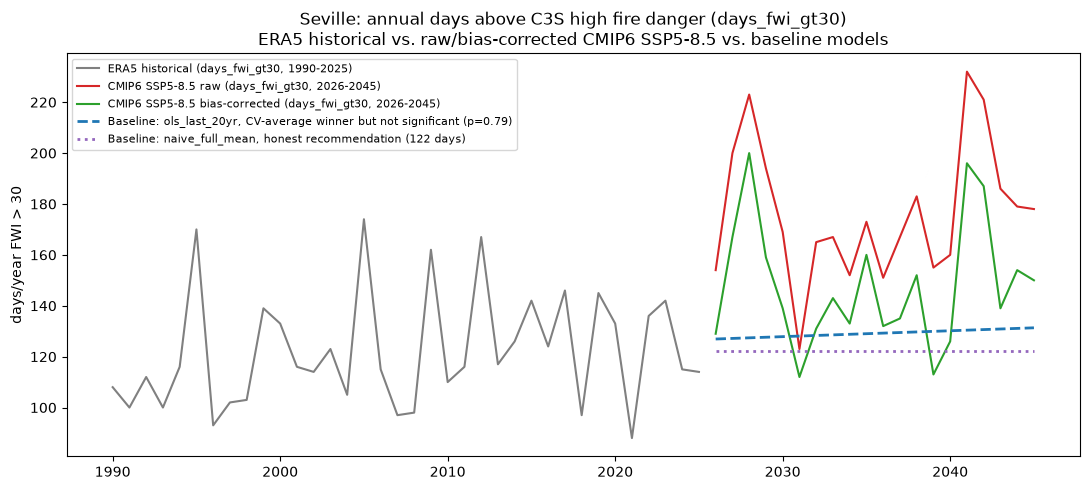

In [26]:
baseline_fwi_naive_full = era5_fwi_annual["days_fwi_gt30"].mean()
last20_fwi = era5_fwi_annual.loc[2006:2025, "days_fwi_gt30"]
lr_fwi = stats.linregress(last20_fwi.index.values.astype(float), last20_fwi.values.astype(float))
fwi_ols_extrapolated = lr_fwi.intercept + lr_fwi.slope * proj_years

print(f"naive_full_mean, ERA5 1990-2025 (Section 13 honest recommendation): {baseline_fwi_naive_full:.1f} days")
print(f"ols_last_20yr, ERA5 2006-2025 (Section 13's technical CV-average winner): "
      f"slope={lr_fwi.slope*10:+.1f} days/decade, p={lr_fwi.pvalue:.2f}, "
      f"{fwi_ols_extrapolated[0]:.1f} days (2026) -> {fwi_ols_extrapolated[-1]:.1f} days (2045)")

cmip6_fwi_annual = pd.read_csv("../data/seville_fwi_cmcc_esm2_ssp585_2026_2045_annual.csv", index_col="year")
cmip6_fwi_annual_raw = pd.read_csv("../data/seville_fwi_cmcc_esm2_ssp585_2026_2045_raw_annual.csv", index_col="year")

fwi_days_compare = pd.DataFrame({
    "era5_historical": era5_fwi_annual["days_fwi_gt30"],
    "cmip6_raw": cmip6_fwi_annual_raw["days_fwi_gt30"],
    "cmip6_biascorrected": cmip6_fwi_annual["days_fwi_gt30"],
})
fwi_days_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_fwi_naive_full, index=cmip6_fwi_annual.index).reindex(fwi_days_compare.index)
fwi_days_compare["baseline_ols_last20yr"] = pd.Series(
    fwi_ols_extrapolated, index=annual_summary.index).reindex(fwi_days_compare.index)
fwi_days_compare.to_csv(OUT / "seville_days_fwi_gt30_era5_vs_cmip6_raw_vs_corrected.csv")

gap_fwi = fwi_days_compare.loc[cmip6_fwi_annual.index, "cmip6_biascorrected"] - baseline_fwi_naive_full
gap_fwi_raw = fwi_days_compare.loc[cmip6_fwi_annual.index, "cmip6_raw"] - baseline_fwi_naive_full
print(f"Bias-corrected CMIP6 days_fwi_gt30 vs. naive_full_mean baseline: mean gap = {gap_fwi.mean():+.1f} days "
      f"(range {gap_fwi.min():+.1f} to {gap_fwi.max():+.1f} across 2026-2045)")
print(f"Raw CMIP6 days_fwi_gt30 vs. naive_full_mean baseline: mean gap = {gap_fwi_raw.mean():+.1f} days "
      f"(range {gap_fwi_raw.min():+.1f} to {gap_fwi_raw.max():+.1f} across 2026-2045)")
print(f"Raw vs. corrected: {fwi_days_compare['cmip6_raw'].mean():.1f} -> "
      f"{fwi_days_compare['cmip6_biascorrected'].mean():.1f} days "
      f"({fwi_days_compare['cmip6_biascorrected'].mean() - fwi_days_compare['cmip6_raw'].mean():+.1f})")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(fwi_days_compare.index, fwi_days_compare["era5_historical"],
        label="ERA5 historical (days_fwi_gt30, 1990-2025)", color="gray")
ax.plot(fwi_days_compare.index, fwi_days_compare["cmip6_raw"],
        label="CMIP6 SSP5-8.5 raw (days_fwi_gt30, 2026-2045)", color="tab:red")
ax.plot(fwi_days_compare.index, fwi_days_compare["cmip6_biascorrected"],
        label="CMIP6 SSP5-8.5 bias-corrected (days_fwi_gt30, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, fwi_days_compare.loc[annual_summary.index, "baseline_ols_last20yr"],
        "--", linewidth=2, color="tab:blue",
        label=f"Baseline: ols_last_20yr, CV-average winner but not significant (p={lr_fwi.pvalue:.2f})")
ax.plot(cmip6_fwi_annual.index, fwi_days_compare.loc[cmip6_fwi_annual.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean, honest recommendation ({baseline_fwi_naive_full:.0f} days)")
ax.set_ylabel("days/year FWI > 30")
ax.set_title("Seville: annual days above C3S high fire danger (days_fwi_gt30)\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP5-8.5 vs. baseline models")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Summary.** Raw CMIP6 `days_fwi_gt30` averages **176.6 days/year** -- bias correction pulls that
down to **147.8 days/year**, a **-28.8 day (-16.3%) reduction**, consistent with Seville's raw model
running both too hot and too dry (documented earlier in this section) and correction fixing both.
This is the opposite direction from Larissa's own raw-vs-corrected FWI comparison
(`FWI_projections_last_2.ipynb` Section 4.1: Larissa's correction *increases* fire days, +11.3%) --
worth remembering that "bias correction reduces projected fire risk" is a Seville-specific finding
here, not a general rule.

**Both baselines land close together, for different reasons.** `naive_full_mean` (122.2 days, flat)
and `ols_last_20yr` (126.9 -> 131.3 days, essentially flat in practice despite being a "trend") sit
within a few days of each other across the whole 2026-2045 window -- the CV check's 1.8% preference
for `ols_last_20yr` is really about it being centred a few days higher, not about it capturing a real
accelerating trend. Against either baseline, bias-corrected CMIP6 runs **+20 to +26 days/year above**
it on average, projecting to roughly **148 days/year**; raw CMIP6 runs roughly **+45 to +54 days/year
above**, at roughly **177 days/year** -- consistent with (and a useful cross-check against)
`FWI_projections_last_2.ipynb`'s own headline number of 126 -> 148 days computed independently via its
1991-2020-vs-2036-2045 window. The year-to-year range is wide in both projected series, reflecting
that a single model/scenario run's fire-weather-day count is considerably noisier than its temperature
indicators.


## 17. What could not be carried over from the ERA5 pipeline

- **Fire Weather Index / `longest_high_run` (Seville's third `Climate_Indicators_Modeling.ipynb`
  indicator) has no path forward here at all.** It's not computed from a formula over ERA5
  variables in this codebase -- it's a directly-downloaded, precomputed product from a completely
  separate Copernicus data source (`cems-fire-historical-v1`, the CEMS Early Warning Data Store,
  pulled by `fetch_seville_fire.py`), requiring local-noon temperature/RH/wind/24h-precip inputs
  this pipeline never assembles. `documentation/projection_data_pull_plan.md` already confirmed
  neither `sis-ecde-climate-indicators` nor `sis-extreme-indices-cmip6` offers an SSP5-8.5
  fire-danger product. This indicator is out of scope for the projection period; the eventual
  `min_spi3`/`tmax_mean`/`longest_high_run` compound comparison in `Climate_Indicators_Modeling.ipynb`
  can only be completed for the first two.
- **Wind rose / prevailing-direction analysis is dropped.** The CMIP6 pull only has scalar
  `sfcWind` (speed), not `u10`/`v10` components -- `wind_direction()` has nothing to compute from.
- **Diurnal cycle and the "how much of the true daily range does sampling capture" comparison don't
  apply.** CMIP6 is daily-native with no sub-daily samples to summarize; there's no intra-day
  variation left to describe.
- **`heat_index_c` (Section 5) is a redefinition, not a like-for-like port** -- computed once per
  day from daily-mean T/RH rather than as the max of six intra-day samples. Named differently from
  the historical `heat_index_max_c` for that reason; don't join the two columns as if comparable.
  Section 12 recomputes it from the bias-corrected `tmean_c`/`rh_mean_percent`, so this same
  caveat applies to the corrected version used in Sections 13-16 too.
- **SPI-3 / `min_spi3` for the projection period is deferred, not attempted here** -- consistent
  with `seville_era5_eda.ipynb` itself, which also defers SPI to a separate notebook
  (`Calculating_SPI_for_Seville.ipynb`) rather than computing it inline. `precip_mm_day` summed to
  monthly is exactly what a projection-period SPI-3 notebook would need as input (scored against
  the existing ERA5 1990-2020 gamma fit, never refit -- same principle as Section 6's temperature
  threshold, and the same principle Section 12 follows for its own 1990-2014 fitting period);
  building that notebook is the natural next step, not part of this one.

## 18. Summary

Outputs written to `eda_results/eda_outputs_seville_projection/`:

**Raw (Sections 1-11):**
- `seville_projection_daily.csv` -- daily frame, grid-averaged, unit-converted
- `seville_projection_heatwave_events.csv` -- heatwave events, fixed ERA5 1990-2020 P90 threshold
- `seville_projection_annual_summary.csv` -- annual indicator table
- `seville_projection_trends.csv` -- within-projection-period trend table (2026-2045)
- `seville_projection_vs_era5_extrapolation.csv` -- `tmax_mean` gap vs. ERA5 trend extrapolation

**Bias-corrected (Sections 12-16):**
- `seville_projection_daily_biascorrected_2026_2045.csv` -- Equidistant-CDF-Matching corrected
  daily series
- `seville_projection_bias_correction_diagnostics_2026_2045.csv` -- per-variable, per-month bias
  and correction magnitude
- `seville_projection_heatwave_events_biascorrected.csv` -- heatwave events on the corrected series
- `seville_projection_annual_summary_biascorrected.csv` -- annual indicator table, corrected series
- `seville_projection_before_after_bias_correction_summary.csv` -- the Section 15 before/after
  comparison table (20-year annual means, raw vs. corrected, key indicators)
- `seville_projection_trends_biascorrected.csv` -- trend table on the corrected series

**Headline result** (Section 15): bias correction shifts `tmax_mean`/`tmin_mean` down by roughly
the same ~0.9-1.0 degC measured in the original ERA5-vs-cmcc_esm2 model comparison, which in turn
reduces (but does not eliminate) the fixed-threshold hot-day and tropical-night counts -- see the
Section 15 bar chart for the exact percentage shift per indicator. Trend directions (Section 16)
are essentially unchanged by correction, as expected from a roughly level-shifting correction.

Next steps: build the equivalent Larissa notebook (same structure, `tmin_mean`/`precip_scaled`/
`max_week_precip_mm` as the relevant indicators rather than Seville's heat/drought/fire set,
including its own bias-correction sections); a projection-period SPI-3 notebook per Section 17;
and, once Larissa exists, extend `Climate_Indicators_Modeling.ipynb`'s Section 10 from prose into
an actual comparison using these exported CSVs (bias-corrected versions preferred where available).

## 19. Key findings summary

Synthesizes Section 16's six comparison panels (`tas_mean`, `tmax_mean`, `precip_total`, `min_spi3`,
`t2m_mean` revisited, `days_fwi_gt30`) into the themes that actually matter for reading this notebook's
results, rather than re-listing every number panel by panel.

### 1. A consistent, modest warming signal -- real but not statistically confirmed

Three independently-built baselines all agree on direction and rough magnitude: bias-corrected CMIP6
SSP5-8.5 runs **+0.33 to +0.35 degC warmer** than the best-supported historical extrapolation --
`ols_last_20yr` for `tmax_mean` (+0.35 degC) and `ols_full_history` for `t2m_mean` (+0.33 degC), two
baseline models chosen independently in `Climate_Indicators_Modeling.ipynb` for different reasons, not
tuned to agree with each other. That consistency is itself informative. But per Section 16's
significance table, **none of the within-projection-period trends are statistically significant**
(`tas_mean`, `tmax_mean`, `tmin_mean`, `heat_index_mean`, `tas_p95` all `False` at p<0.05, raw and
corrected alike) -- 20 years from a single model/scenario run isn't enough data to confirm the gap is
a real acceleration rather than noise, even though the direction is consistent across every baseline
tried.

### 2. Bias correction fixes a badly broken raw precipitation signal -- but the fix has its own artifact

Raw CMIP6 `precip_total` (248mm/yr) is roughly **half** of Seville's actual historical average
(~487mm/yr, ERA5 1990-2025) -- an implausible raw output, not a subtle bias. Correction brings it to a
realistic **453.71mm/yr (+82.84%)**, landing close to the historical mean, which is the correction
behaving as intended. But the *method* used to get there (multiplicative Equidistant CDF Matching)
disproportionately amplifies already-wet months -- traced in detail while building
`Calculating_SPI_for_Seville_Projection.ipynb`, where it showed up as a cluster of spuriously
"severely wet" SPI-3 readings concentrated in September/October/January. Anything built downstream of
the corrected precipitation series (SPI-3 here, and partly `days_fwi_gt30`, since FWI depends on
precip/RH too) inherits that artifact, not just the underlying climate signal.

### 3. Drought (`min_spi3`) points toward more severe conditions, even after fixing the precip bias

Bias-corrected projected `min_spi3` runs **-0.84 below** the flat historical baseline (-1.44) --
deeper, more severe annual drought minimums than Seville's historical norm. This holds up *after*
correcting the precipitation bias, so it isn't simply an artifact of raw CMIP6 being too dry --
correction, if anything, makes drought severity a more trustworthy number than the raw series would
have given.

### 4. Fire danger (`days_fwi_gt30`) is the largest relative signal, and correction cuts the risk here -- not always

Raw CMIP6 fire-danger days (**176.6/yr**) look alarming, but that's partly an artifact of the raw
model running both too hot *and* too dry simultaneously (Section 15's before/after table: raw
`tmax_mean` -3.80%, `precip_total` +82.84% after correction -- both directions inflate raw FWI).
Correction brings it down to **147.8/yr (-16.3%)** -- still meaningfully above Seville's historical
baselines (122.2-131.3 days depending on which of the two baseline models is used), so a real
projected increase survives correction, just a smaller and more defensible one than the raw number
would suggest. **This direction is Seville-specific, not universal**: `FWI_projections_last_2.ipynb`
Section 4.1 found Larissa's correction moves the *opposite* way (+11.3%, raw understates fire risk
there) -- a reminder not to generalize "correction always reduces projected fire risk" from this one
city.

### 5. Heat-hazard and hot-day indicators drop substantially after correction -- not a minor adjustment

From Section 15's before/after table (20-year annual means, raw vs. corrected):

| Indicator | Raw | Corrected | Change |
|---|---|---|---|
| `tmax_mean` | 25.36 degC | 24.39 degC | -3.80% |
| `tmin_mean` | 16.48 degC | 15.04 degC | -8.77% |
| `tas_mean` | 20.82 degC | 19.86 degC | -4.58% |
| days tmax>=35C | 67.15 | 43.95 | -34.55% |
| tropical nights | 131.30 | 89.30 | -31.99% |
| heatwaves/yr | 14.95 | 9.75 | -34.78% |
| heatwave days/yr | 94.95 | 53.80 | -43.34% |

The raw model substantially overstates nearly every heat-hazard indicator -- bias correction isn't a
cosmetic adjustment here, it changes the headline magnitude by a third to nearly half for the
threshold-based counts. Any of this notebook's raw-series numbers, quoted on their own without the
corrected comparison, would meaningfully overstate Seville's projected heat risk.

### 6. Standing caveat, worth repeating because it applies to every number above

Single model (`cmcc_esm2`), single scenario (SSP5-8.5), no ensemble spread -- every figure in this
notebook is *directional risk under one plausible pathway*, not a calibrated forecast. Where a gap
against a historical baseline doesn't reach statistical significance (most of them, at this 20-year
horizon), read it as "consistent with," not "proof of," continued or accelerating change.
